In [1]:
# ============================================================
# CELL 1: Imports + original cleanup/preprocessing functions
#
# Standard library, then third-party numerics/plotting, then scipy/
# sklearn. RANDOM_STATE is fixed once here so every randomized step used
# later (e.g. the PCA below) is reproducible across re-runs.
# ============================================================

import os
import glob
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter

from sklearn.svm import SVC
from sklearn.model_selection import LeaveOneGroupOut, StratifiedKFold, GroupKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

# Fixed seed for reproducibility of any randomized step in this notebook
# (e.g. the PCA decomposition used in the blank-separability audit below).
RANDOM_STATE = 42

print("Imports loaded successfully.")

Imports loaded successfully.


In [2]:
# ============================================================
# CELL 2: Original cleanup function from classification notebook
#
# Three reusable building blocks for the rest of the notebook:
#   cleanup()                            raw .txt file -> numeric spectrum
#   snv_transform()                      row-wise Standard Normal Variate
#   original_classification_preprocess() the original fixed 500-900 nm +
#                                         SNV pipeline used as the
#                                         non-nested classification baseline
# ============================================================

def cleanup(filepath):
    """
    Read one raw spectrum .txt file and convert it into a clean dataframe
    with numeric Wavelength and Intensity columns.

    This intentionally follows the original classification notebook:
    - drop first 12 rows
    - split first column into Wavelength and Intensity
    """
    df = pd.read_csv(filepath)
    df = df.drop(df.index[:12])
    df[["Wavelength", "Intensity"]] = df.iloc[:, 0].str.split(n=1, expand=True)
    df["Wavelength"] = pd.to_numeric(df["Wavelength"])
    df["Intensity"] = pd.to_numeric(df["Intensity"])
    return df[["Wavelength", "Intensity"]]


def plot_spectrum(df, title="Spectrum"):
    """Quick-look line plot of one Wavelength/Intensity spectrum."""
    plt.figure(figsize=(8, 4))
    plt.plot(df["Wavelength"], df["Intensity"])
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Intensity")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def snv_transform(X):
    """
    Standard Normal Variate preprocessing.
    Applied row-wise, spectrum by spectrum.
    """
    row_mean = np.mean(X, axis=1, keepdims=True)
    row_std = np.std(X, axis=1, keepdims=True)

    # Prevent divide-by-zero if any spectrum is flat.
    row_std[row_std == 0] = 1.0

    return (X - row_mean) / row_std


def original_classification_preprocess(X_raw, wavelengths, wl_min=500, wl_max=900):
    """
    Original classification preprocessing:
    1. Crop wavelengths to 500–900 nm.
    2. Apply SNV.
    """
    mask = (wavelengths >= wl_min) & (wavelengths <= wl_max)

    X_cropped = X_raw[:, mask]
    wl_active = wavelengths[mask]

    X_snv = snv_transform(X_cropped)

    return X_snv, wl_active, mask


print("Cleanup and preprocessing functions ready.")

Cleanup and preprocessing functions ready.


In [3]:
# ============================================================
# CELL 3: Build master matrix
#
# Walks DATA_ROOT/<gas>/*.txt for every gas in TARGETS, parses each file
# with cleanup(), and stacks the spectra into one wide matrix
# (rows = spectra, columns = pixels) alongside a metadata table
# (gas, concentration, filename). Corresponds to the "Data loading" and
# "Integrity checks" stages of the pipeline schematic (Figure 1).
# ============================================================

def extract_ppm_from_filename(filename):
    """
    Extract concentration from filenames like:
    Ethanol_10ppm_xxx.txt
    Acetone_0ppm_xxx.txt

    If concentration cannot be parsed, returns 0.0,
    matching the behavior of your original notebook.
    """
    base = os.path.basename(filename).replace(".txt", "")

    match = re.search(r"([0-9]+(?:\.[0-9]+)?)\s*ppm", base, flags=re.IGNORECASE)
    if match:
        return float(match.group(1))

    # Fallback to old style: split by underscore and read second part.
    try:
        parts = base.split("_")
        return float(parts[1].replace("ppm", ""))
    except Exception:
        return 0.0


def build_master_matrix(data_root, target_gases):
    """
    Load every .txt spectrum for each gas folder under data_root and
    assemble them into one master dataframe.

    Returns
    -------
    final_df : pd.DataFrame
        Metadata columns (Gas_Type, Concentration, Filename, Filepath)
        concatenated with one Pixel_<i> column per wavelength.
    wavelengths : np.ndarray
        Shared wavelength axis, taken from the first file read and
        checked against every subsequent file below.
    """
    all_intensities = []
    metadata = []
    wavelengths = None

    for gas in target_gases:
        folder_path = os.path.join(data_root, gas)
        files = sorted(glob.glob(os.path.join(folder_path, "*.txt")))

        print(f"{gas}: found {len(files)} files in {folder_path}")

        for f in files:
            df_temp = cleanup(f)

            if wavelengths is None:
                wavelengths = df_temp["Wavelength"].values
            else:
                # Integrity check: every spectrum must share the same
                # pixel grid. A mismatch would mean a different
                # instrument setting or a truncated file slipped into
                # the dataset, which would silently corrupt the
                # stacked matrix built below.
                if len(df_temp["Wavelength"].values) != len(wavelengths):
                    raise ValueError(f"Wavelength length mismatch in file: {f}")

            filename = os.path.basename(f)
            ppm = extract_ppm_from_filename(filename)

            metadata.append({
                "Gas_Type": gas,
                "Concentration": ppm,
                "Filename": filename,
                "Filepath": f
            })

            all_intensities.append(df_temp["Intensity"].values)

    if len(all_intensities) == 0:
        raise ValueError("No spectra found. Check DATA_ROOT and TARGETS.")

    pixel_df = pd.DataFrame(all_intensities)
    pixel_df.columns = [f"Pixel_{i}" for i in range(pixel_df.shape[1])]

    meta_df = pd.DataFrame(metadata)
    final_df = pd.concat([meta_df, pixel_df], axis=1)

    return final_df, wavelengths


# CHANGE THIS ONLY IF NEEDED
DATA_ROOT = "../data/"
TARGETS = ["Ethanol", "Acetone", "Ammonia"]

df_master, wl_reference = build_master_matrix(DATA_ROOT, TARGETS)

metadata_cols = ["Gas_Type", "Concentration", "Filename", "Filepath"]
X_raw = df_master.drop(columns=metadata_cols).values

print("\nMaster matrix created.")
print(f"df_master shape: {df_master.shape}")
print(f"X_raw shape:     {X_raw.shape}")
print(f"Wavelengths:     {wl_reference.min():.2f} to {wl_reference.max():.2f} nm")
print("\nClass counts:")
print(df_master["Gas_Type"].value_counts())
print("\nConcentration counts:")
print(df_master["Concentration"].value_counts().sort_index())

Ethanol: found 48 files in ../data/Ethanol
Acetone: found 48 files in ../data/Acetone
Ammonia: found 42 files in ../data/Ammonia

Master matrix created.
df_master shape: (138, 3652)
X_raw shape:     (138, 3648)
Wavelengths:     194.21 to 1121.27 nm

Class counts:
Gas_Type
Ethanol    48
Acetone    48
Ammonia    42
Name: count, dtype: int64

Concentration counts:
Concentration
0.0      6
1.0      6
2.0      9
3.0      6
4.0      9
5.0      6
6.0      3
8.0      3
10.0     9
12.0     3
14.0     3
16.0     3
18.0     3
20.0     9
25.0     3
30.0     9
35.0     3
40.0     9
50.0     6
60.0     6
70.0     6
80.0     6
90.0     6
100.0    6
Name: count, dtype: int64


Representative spectra selected:


,Gas_Type,Requested_Concentration,Plotted_Concentration,Filename
0,Acetone,20,20.0,acetone_20ppm_1.txt
1,Ammonia,20,20.0,ammonia_20ppm_1.txt
2,Ethanol,20,20.0,ethanol_20ppm_1.txt


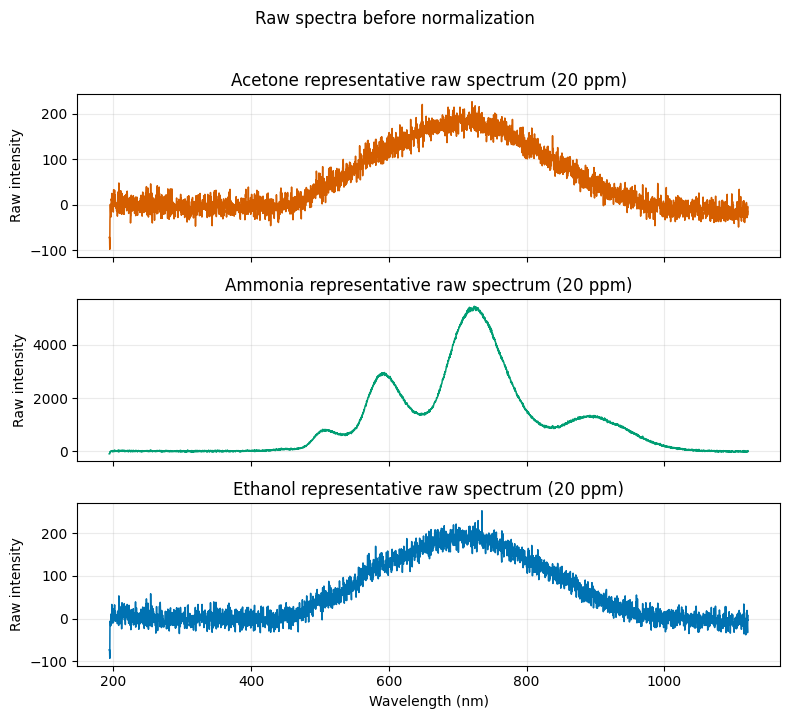

Saved: figures\F1a_raw_spectra_separate_panels.png
Saved: figures\F1a_raw_spectra_separate_panels.pdf


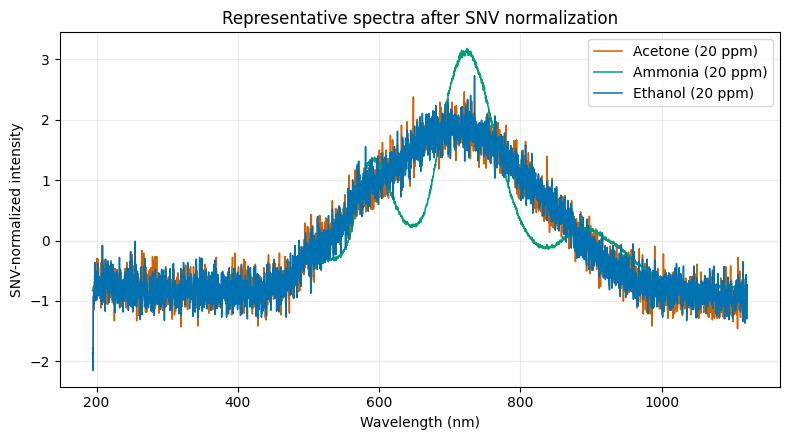

Saved: figures\F1b_snv_normalized_spectra_overlay.png
Saved: figures\F1b_snv_normalized_spectra_overlay.pdf


In [4]:
# ============================================================
# F1 IMPROVED: Raw spectra panels + SNV-normalized overlay
# Paste in CLASSIFICATION notebook after df_master and wl_reference exist.
#
# Produces the paper's Figure 2a (raw, per-gas panels) and Figure 2b
# (SNV-normalized overlay) using one representative spectrum per gas,
# all drawn from the same requested concentration (~20 ppm) so the
# comparison across gases is fair.
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTDIR = "figures"
os.makedirs(OUTDIR, exist_ok=True)

GAS_COLORS = {
    "Ethanol": "#0072B2",
    "Acetone": "#D55E00",
    "Ammonia": "#009E73"
}

def save_figure(fig, name):
    """Save fig as both PNG (300 dpi) and PDF under OUTDIR/<name>."""
    png_path = os.path.join(OUTDIR, f"{name}.png")
    pdf_path = os.path.join(OUTDIR, f"{name}.pdf")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")

def snv_1d(spectrum):
    """SNV-normalize a single 1-D spectrum (mean 0, std 1)."""
    spectrum = np.asarray(spectrum, dtype=float)
    std = spectrum.std()
    if std == 0:
        std = 1.0
    return (spectrum - spectrum.mean()) / std

def get_pixel_columns(df_master, pixel_prefix="Pixel_"):
    """Return the Pixel_<i> columns of df_master, sorted by pixel index."""
    pix_cols = [c for c in df_master.columns if c.startswith(pixel_prefix)]
    pix_cols = sorted(pix_cols, key=lambda x: int(x.split("_")[1]))
    return pix_cols

def choose_representative_rows(df_master, requested_conc=20):
    """
    Choose one representative spectrum per gas at the nearest available
    concentration to requested_conc.

    Using the same requested concentration makes the figure fairer.
    """
    chosen_rows = []

    for gas, sub in df_master.groupby("Gas_Type"):
        available_concs = np.sort(sub["Concentration"].unique())
        target_conc = available_concs[np.argmin(np.abs(available_concs - requested_conc))]

        row = sub[sub["Concentration"] == target_conc].iloc[0]

        chosen_rows.append({
            "Gas_Type": gas,
            "Requested_Concentration": requested_conc,
            "Plotted_Concentration": target_conc,
            "Filename": row["Filename"] if "Filename" in row.index else "not available",
            "Row": row
        })

    return chosen_rows

pix_cols = get_pixel_columns(df_master)

chosen = choose_representative_rows(
    df_master=df_master,
    requested_conc=20
)

chosen_summary = pd.DataFrame([
    {
        "Gas_Type": item["Gas_Type"],
        "Requested_Concentration": item["Requested_Concentration"],
        "Plotted_Concentration": item["Plotted_Concentration"],
        "Filename": item["Filename"]
    }
    for item in chosen
])

print("Representative spectra selected:")
display(chosen_summary)

# ============================================================
# F1a: Raw spectra as separate panels
# ============================================================

fig, axes = plt.subplots(
    nrows=len(chosen),
    ncols=1,
    figsize=(8, 7),
    sharex=True
)

if len(chosen) == 1:
    axes = [axes]

for ax, item in zip(axes, chosen):
    gas = item["Gas_Type"]
    conc = item["Plotted_Concentration"]
    spectrum = item["Row"][pix_cols].values.astype(float)

    ax.plot(
        wl_reference,
        spectrum,
        linewidth=1.1,
        color=GAS_COLORS.get(gas, None)
    )

    ax.set_ylabel("Raw intensity")
    ax.set_title(f"{gas} representative raw spectrum ({conc:g} ppm)")
    ax.grid(alpha=0.25)

axes[-1].set_xlabel("Wavelength (nm)")
fig.suptitle("Raw spectra before normalization", y=1.02)
plt.tight_layout()
plt.show()

save_figure(fig, "F1a_raw_spectra_separate_panels")


# ============================================================
# F1b: SNV-normalized overlay
# ============================================================

fig, ax = plt.subplots(figsize=(8, 4.5))

for item in chosen:
    gas = item["Gas_Type"]
    conc = item["Plotted_Concentration"]
    spectrum = item["Row"][pix_cols].values.astype(float)

    spectrum_snv = snv_1d(spectrum)

    ax.plot(
        wl_reference,
        spectrum_snv,
        linewidth=1.1,
        label=f"{gas} ({conc:g} ppm)",
        color=GAS_COLORS.get(gas, None)
    )

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("SNV-normalized intensity")
ax.set_title("Representative spectra after SNV normalization")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

save_figure(fig, "F1b_snv_normalized_spectra_overlay")

In [5]:
# ============================================================
# CELL 4: Metadata audit + corrected labels
#
# This is the confound-correction step the paper's gas-ID task depends
# on: a 0 ppm "blank" measurement has no chemical identity, so labeling
# it as Ethanol/Acetone/Ammonia (by folder of origin) would let the
# classifier learn to recognize blanks rather than gases. Splitting the
# dataset into df_nonzero (the real gas-ID task) and df_blank (used in
# the audit cells below) removes that confound.
# ============================================================

df_cls = df_master.copy()

# ------------------------------------------------------------
# Original label from folder/gas name
# ------------------------------------------------------------
df_cls["Original_Gas_Label"] = df_cls["Gas_Type"]

# ------------------------------------------------------------
# Corrected classification label:
# 0 ppm is chemically a blank, not Ethanol/Acetone/Ammonia.
# ------------------------------------------------------------
df_cls["Gas_ID_Label_With_Blank"] = np.where(
    df_cls["Concentration"] == 0,
    "Blank",
    df_cls["Gas_Type"]
)

# ------------------------------------------------------------
# Nonzero-only gas identity dataset
# This will become the main gas-ID classification dataset.
# ------------------------------------------------------------
df_nonzero = df_cls[df_cls["Concentration"] > 0].copy()
df_blank = df_cls[df_cls["Concentration"] == 0].copy()

print("=" * 80)
print("FULL DATASET SUMMARY")
print("=" * 80)
print(f"Total spectra: {len(df_cls)}")
print(f"Nonzero spectra: {len(df_nonzero)}")
print(f"Blank / 0 ppm spectra: {len(df_blank)}")

print("\nOriginal gas label counts:")
print(df_cls["Original_Gas_Label"].value_counts())

print("\nCorrected label counts where 0 ppm = Blank:")
print(df_cls["Gas_ID_Label_With_Blank"].value_counts())

print("\nConcentration x original gas table:")
display(
    pd.crosstab(
        df_cls["Concentration"],
        df_cls["Original_Gas_Label"],
        margins=True
    )
)

print("\nBlank samples by original gas folder:")
display(
    df_blank[["Original_Gas_Label", "Concentration", "Filename"]]
    .sort_values(["Original_Gas_Label", "Filename"])
    .reset_index(drop=True)
)

print("\nNonzero gas identity class counts:")
print(df_nonzero["Original_Gas_Label"].value_counts())

# ------------------------------------------------------------
# Basic sanity checks
# ------------------------------------------------------------
assert len(df_nonzero) + len(df_blank) == len(df_cls)
assert (df_blank["Concentration"] == 0).all()
assert (df_nonzero["Concentration"] > 0).all()

print("\nMetadata audit completed successfully.")

FULL DATASET SUMMARY
Total spectra: 138
Nonzero spectra: 132
Blank / 0 ppm spectra: 6

Original gas label counts:
Original_Gas_Label
Ethanol    48
Acetone    48
Ammonia    42
Name: count, dtype: int64

Corrected label counts where 0 ppm = Blank:
Gas_ID_Label_With_Blank
Ethanol    45
Acetone    45
Ammonia    42
Blank       6
Name: count, dtype: int64

Concentration x original gas table:


Original_Gas_Label,Acetone,Ammonia,Ethanol,All
Concentration,,,,
0.0,3,0,3,6
1.0,3,0,3,6
2.0,3,3,3,9
3.0,3,0,3,6
4.0,3,3,3,9
5.0,3,0,3,6
6.0,0,3,0,3
8.0,0,3,0,3
10.0,3,3,3,9



Blank samples by original gas folder:


,Original_Gas_Label,Concentration,Filename
0,Acetone,0.0,acetone_0ppm_1.txt
1,Acetone,0.0,acetone_0ppm_2.txt
2,Acetone,0.0,acetone_0ppm_3.txt
3,Ethanol,0.0,ethanol_0ppm_1.txt
4,Ethanol,0.0,ethanol_0ppm_2.txt
5,Ethanol,0.0,ethanol_0ppm_3.txt



Nonzero gas identity class counts:
Original_Gas_Label
Ethanol    45
Acetone    45
Ammonia    42
Name: count, dtype: int64

Metadata audit completed successfully.


BASELINE INPUT CHECK
Original X_raw shape:          (138, 3648)
Baseline X shape after crop:   (138, 1579)
Active wavelength range:       500.05–899.93 nm
Number of concentration folds: 24

Concentration groups:
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(8.0), np.float64(10.0), np.float64(12.0), np.float64(14.0), np.float64(16.0), np.float64(18.0), np.float64(20.0), np.float64(25.0), np.float64(30.0), np.float64(35.0), np.float64(40.0), np.float64(50.0), np.float64(60.0), np.float64(70.0), np.float64(80.0), np.float64(90.0), np.float64(100.0)]

BASELINE OVERALL RESULTS — ORIGINAL / CONFOUNDED PROTOCOL
Accuracy:          0.9493  (94.93%)
Balanced accuracy: 0.9514  (95.14%)
Macro F1:          0.9513
Weighted F1:       0.9492

Fold-level results:


,Fold,Heldout_Concentration,N_Test,Accuracy,Balanced_Accuracy
0,1,0.0,6,1.000000,1.000000
1,2,1.0,6,1.000000,1.000000
2,3,2.0,9,0.888889,0.888889
3,4,3.0,6,0.666667,0.666667
4,5,4.0,9,0.888889,0.888889
5,6,5.0,6,1.000000,1.000000
6,7,6.0,3,1.000000,1.000000
7,8,8.0,3,1.000000,1.000000
8,9,10.0,9,0.888889,0.888889
9,10,12.0,3,1.000000,1.000000



Classification report:
              precision    recall  f1-score   support

     Acetone       0.90      0.96      0.93        48
     Ammonia       1.00      1.00      1.00        42
     Ethanol       0.96      0.90      0.92        48

    accuracy                           0.95       138
   macro avg       0.95      0.95      0.95       138
weighted avg       0.95      0.95      0.95       138



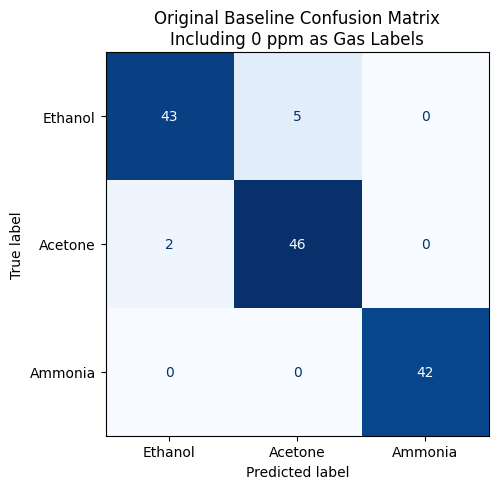


Per-concentration accuracy from baseline predictions:


,Concentration,N,Accuracy
0,0.0,6,0.666667
1,1.0,6,0.000000
2,2.0,9,0.000000
3,3.0,6,0.166667
4,4.0,9,0.222222
5,5.0,6,0.000000
6,6.0,3,0.000000
7,8.0,3,0.000000
8,10.0,9,0.333333
9,12.0,3,1.000000



Baseline prediction table head:


,Original_Gas_Label,Gas_ID_Label_With_Blank,Concentration,Filename,Predicted_Gas_Label,Correct
0,Ethanol,Blank,0.0,ethanol_0ppm_1.txt,Ethanol,True
1,Ethanol,Blank,0.0,ethanol_0ppm_2.txt,Ethanol,True
2,Ethanol,Blank,0.0,ethanol_0ppm_3.txt,Ethanol,True
3,Ethanol,Ethanol,100.0,ethanol_100ppm_1.txt,Acetone,False
4,Ethanol,Ethanol,100.0,ethanol_100ppm_2.txt,Acetone,False
5,Ethanol,Ethanol,100.0,ethanol_100ppm_3.txt,Acetone,False
6,Ethanol,Ethanol,10.0,ethanol_10ppm_1.txt,Ethanol,True
7,Ethanol,Ethanol,10.0,ethanol_10ppm_2.txt,Ethanol,True
8,Ethanol,Ethanol,10.0,ethanol_10ppm_3.txt,Ethanol,True
9,Ethanol,Ethanol,1.0,ethanol_1ppm_1.txt,Acetone,False


In [6]:
# ============================================================
# CELL 5: Original baseline classification protocol
# Fixed 500–900 nm + SNV + RBF SVC + LOGO by concentration
# Includes 0 ppm blanks as original gas labels
#
# This intentionally reproduces the historical/confounded protocol
# (0 ppm blanks still labeled by their original gas folder) so it can
# be compared against the corrected nonzero-only protocol later in the
# notebook. It is not the paper's primary result (see Figure 6 /
# Table 9, "Historical ... not final").
# ============================================================

from sklearn.metrics import f1_score

# ------------------------------------------------------------
# Original fixed preprocessing
# ------------------------------------------------------------
X_baseline, wl_baseline, baseline_mask = original_classification_preprocess(
    X_raw,
    wl_reference,
    wl_min=500,
    wl_max=900
)

y_baseline = pd.Series(df_cls["Original_Gas_Label"].values)
groups_conc = pd.Series(df_cls["Concentration"].values)

print("=" * 80)
print("BASELINE INPUT CHECK")
print("=" * 80)
print(f"Original X_raw shape:          {X_raw.shape}")
print(f"Baseline X shape after crop:   {X_baseline.shape}")
print(f"Active wavelength range:       {wl_baseline.min():.2f}–{wl_baseline.max():.2f} nm")
print(f"Number of concentration folds: {groups_conc.nunique()}")
print("\nConcentration groups:")
print(sorted(groups_conc.unique()))

# ------------------------------------------------------------
# Leave-one-concentration-out evaluation
#
# Grouping by Concentration (rather than a plain random/stratified
# split) ensures all 3 replicates of a held-out concentration are
# removed from training together. This is the leakage-safe split unit
# used throughout the notebook: it stops the model from "cheating" by
# seeing a near-identical replicate of the test sample during training.
# ------------------------------------------------------------
logo = LeaveOneGroupOut()

all_true = []
all_pred = []
fold_rows = []

for fold_id, (train_idx, test_idx) in enumerate(
    logo.split(X_baseline, y_baseline, groups=groups_conc),
    start=1
):
    X_train, X_test = X_baseline[train_idx], X_baseline[test_idx]
    y_train, y_test = y_baseline.iloc[train_idx], y_baseline.iloc[test_idx]

    heldout_conc = groups_conc.iloc[test_idx].iloc[0]

    clf = SVC(kernel="rbf", C=10, gamma="scale")
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    fold_acc = accuracy_score(y_test, y_pred)
    fold_bal_acc = balanced_accuracy_score(y_test, y_pred)

    fold_rows.append({
        "Fold": fold_id,
        "Heldout_Concentration": heldout_conc,
        "N_Test": len(test_idx),
        "Accuracy": fold_acc,
        "Balanced_Accuracy": fold_bal_acc
    })

    all_true.extend(y_test.tolist())
    all_pred.extend(y_pred.tolist())

baseline_fold_df = pd.DataFrame(fold_rows)

baseline_acc = accuracy_score(all_true, all_pred)
baseline_bal_acc = balanced_accuracy_score(all_true, all_pred)
baseline_macro_f1 = f1_score(all_true, all_pred, average="macro")
baseline_weighted_f1 = f1_score(all_true, all_pred, average="weighted")

print("\n" + "=" * 80)
print("BASELINE OVERALL RESULTS — ORIGINAL / CONFOUNDED PROTOCOL")
print("=" * 80)
print(f"Accuracy:          {baseline_acc:.4f}  ({baseline_acc * 100:.2f}%)")
print(f"Balanced accuracy: {baseline_bal_acc:.4f}  ({baseline_bal_acc * 100:.2f}%)")
print(f"Macro F1:          {baseline_macro_f1:.4f}")
print(f"Weighted F1:       {baseline_weighted_f1:.4f}")

print("\nFold-level results:")
display(baseline_fold_df)

print("\nClassification report:")
print(classification_report(all_true, all_pred))

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------
labels_order = ["Ethanol", "Acetone", "Ammonia"]

cm = confusion_matrix(all_true, all_pred, labels=labels_order)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels_order
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
plt.title("Original Baseline Confusion Matrix\nIncluding 0 ppm as Gas Labels")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Save baseline predictions for later comparison
# ------------------------------------------------------------
baseline_pred_df = df_cls[[
    "Original_Gas_Label",
    "Gas_ID_Label_With_Blank",
    "Concentration",
    "Filename"
]].copy()

baseline_pred_df["Predicted_Gas_Label"] = all_pred
baseline_pred_df["Correct"] = (
    baseline_pred_df["Original_Gas_Label"] == baseline_pred_df["Predicted_Gas_Label"]
)

print("\nPer-concentration accuracy from baseline predictions:")
display(
    baseline_pred_df
    .groupby("Concentration")
    .agg(
        N=("Correct", "size"),
        Accuracy=("Correct", "mean")
    )
    .reset_index()
)

print("\nBaseline prediction table head:")
display(baseline_pred_df.head(10))

Corrected Baseline: Nonzero-Only Gas ID
Fixed 500–900 nm + SNV + RBF SVC + Leave-One-Concentration-Out
N spectra:          132
N groups:           23
Groups:             [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(8.0), np.float64(10.0), np.float64(12.0), np.float64(14.0), np.float64(16.0), np.float64(18.0), np.float64(20.0), np.float64(25.0), np.float64(30.0), np.float64(35.0), np.float64(40.0), np.float64(50.0), np.float64(60.0), np.float64(70.0), np.float64(80.0), np.float64(90.0), np.float64(100.0)]
Accuracy:           0.9242  (92.42%)
Balanced accuracy:  0.9259  (92.59%)
Macro F1:           0.9258
Weighted F1:        0.9241

Fold-level results:


,Fold,Heldout_Concentration,N_Test,Classes_In_Test,Accuracy,Balanced_Accuracy
0,1,1.0,6,"Acetone, Ethanol",0.666667,0.666667
1,2,2.0,9,"Acetone, Ammonia, Ethanol",0.777778,0.777778
2,3,3.0,6,"Acetone, Ethanol",0.833333,0.833333
3,4,4.0,9,"Acetone, Ammonia, Ethanol",0.888889,0.888889
4,5,5.0,6,"Acetone, Ethanol",1.000000,1.000000
5,6,6.0,3,Ammonia,1.000000,1.000000
6,7,8.0,3,Ammonia,1.000000,1.000000
7,8,10.0,9,"Acetone, Ammonia, Ethanol",0.888889,0.888889
8,9,12.0,3,Ammonia,1.000000,1.000000
9,10,14.0,3,Ammonia,1.000000,1.000000



Classification report:
              precision    recall  f1-score   support

     Ethanol       0.93      0.84      0.88        45
     Acetone       0.86      0.93      0.89        45
     Ammonia       1.00      1.00      1.00        42

    accuracy                           0.92       132
   macro avg       0.93      0.93      0.93       132
weighted avg       0.93      0.92      0.92       132


Per-Concentration accuracy:


,Concentration,N,Accuracy
0,1.0,6,0.666667
1,2.0,9,0.777778
2,3.0,6,0.833333
3,4.0,9,0.888889
4,5.0,6,1.000000
5,6.0,3,1.000000
6,8.0,3,1.000000
7,10.0,9,0.888889
8,12.0,3,1.000000
9,14.0,3,1.000000


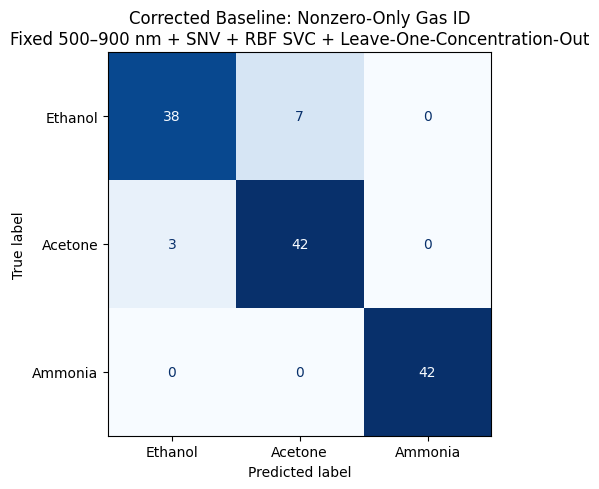


Nonzero-only prediction table head:


,Original_Gas_Label,Concentration,Filename,OOF_Predicted_Label,Correct
0,Ethanol,100.0,ethanol_100ppm_1.txt,Ethanol,True
1,Ethanol,100.0,ethanol_100ppm_2.txt,Ethanol,True
2,Ethanol,100.0,ethanol_100ppm_3.txt,Ethanol,True
3,Ethanol,10.0,ethanol_10ppm_1.txt,Acetone,False
4,Ethanol,10.0,ethanol_10ppm_2.txt,Ethanol,True
5,Ethanol,10.0,ethanol_10ppm_3.txt,Ethanol,True
6,Ethanol,1.0,ethanol_1ppm_1.txt,Acetone,False
7,Ethanol,1.0,ethanol_1ppm_2.txt,Acetone,False
8,Ethanol,1.0,ethanol_1ppm_3.txt,Ethanol,True
9,Ethanol,20.0,ethanol_20ppm_1.txt,Ethanol,True


In [7]:
# ============================================================
# CELL 6: Safe LOGO evaluator + nonzero-only gas-ID baseline
#
# evaluate_logo_svc() generalizes the LOGO loop from Cell 5 into a
# reusable function so it can be applied with different grouping
# columns (Concentration here, Replicate_ID later in Cell 10) without
# duplicating the loop body. Predictions are written back using
# test_idx positions rather than appended in fold order, so the output
# row order always matches df_eval even if folds are processed out of
# their natural order.
# ============================================================

def evaluate_logo_svc(
    X,
    df_eval,
    y_col,
    group_col,
    labels_order,
    title,
    kernel="rbf",
    C=10,
    gamma="scale",
    show_confusion=True
):
    """
    Safe Leave-One-Group-Out classifier evaluation.
    Predictions are stored in the correct original row order.

    Parameters
    ----------
    X : np.ndarray
        Feature matrix aligned with df_eval rows.
    df_eval : pd.DataFrame
        Metadata dataframe aligned with X rows.
    y_col : str
        Label column name.
    group_col : str
        Grouping column for LOGO.
    labels_order : list
        Class order for reports/confusion matrix.
    title : str
        Printed title.
    """

    df_eval = df_eval.reset_index(drop=True).copy()
    y = pd.Series(df_eval[y_col].values)
    groups = pd.Series(df_eval[group_col].values)

    logo = LeaveOneGroupOut()

    oof_pred = np.empty(len(df_eval), dtype=object)
    oof_true = y.values.copy()

    fold_rows = []

    for fold_id, (train_idx, test_idx) in enumerate(
        logo.split(X, y, groups=groups),
        start=1
    ):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        heldout_group = groups.iloc[test_idx].iloc[0]

        clf = SVC(kernel=kernel, C=C, gamma=gamma)
        clf.fit(X_train, y_train)

        y_pred = clf.predict(X_test)
        oof_pred[test_idx] = y_pred

        fold_rows.append({
            "Fold": fold_id,
            f"Heldout_{group_col}": heldout_group,
            "N_Test": len(test_idx),
            "Classes_In_Test": ", ".join(sorted(y_test.unique())),
            "Accuracy": accuracy_score(y_test, y_pred),
            "Balanced_Accuracy": balanced_accuracy_score(y_test, y_pred)
        })

    fold_df = pd.DataFrame(fold_rows)

    acc = accuracy_score(oof_true, oof_pred)
    bal_acc = balanced_accuracy_score(oof_true, oof_pred)
    macro_f1 = f1_score(oof_true, oof_pred, average="macro")
    weighted_f1 = f1_score(oof_true, oof_pred, average="weighted")

    print("=" * 80)
    print(title)
    print("=" * 80)
    print(f"N spectra:          {len(df_eval)}")
    print(f"N groups:           {groups.nunique()}")
    print(f"Groups:             {sorted(groups.unique())}")
    print(f"Accuracy:           {acc:.4f}  ({acc * 100:.2f}%)")
    print(f"Balanced accuracy:  {bal_acc:.4f}  ({bal_acc * 100:.2f}%)")
    print(f"Macro F1:           {macro_f1:.4f}")
    print(f"Weighted F1:        {weighted_f1:.4f}")

    print("\nFold-level results:")
    display(fold_df)

    print("\nClassification report:")
    print(classification_report(oof_true, oof_pred, labels=labels_order))

    pred_df = df_eval.copy()
    pred_df["OOF_Predicted_Label"] = oof_pred
    pred_df["Correct"] = pred_df[y_col] == pred_df["OOF_Predicted_Label"]

    print(f"\nPer-{group_col} accuracy:")
    display(
        pred_df
        .groupby(group_col)
        .agg(
            N=("Correct", "size"),
            Accuracy=("Correct", "mean")
        )
        .reset_index()
        .sort_values(group_col)
    )

    if show_confusion:
        cm = confusion_matrix(oof_true, oof_pred, labels=labels_order)

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=labels_order
        )

        fig, ax = plt.subplots(figsize=(6, 5))
        disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
        plt.title(title)
        plt.tight_layout()
        plt.show()

    metrics = {
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    }

    return pred_df, fold_df, metrics


# ------------------------------------------------------------
# Nonzero-only gas identity dataset
# This is the corrected main gas-ID baseline: blanks are excluded so
# the classifier can only learn gas-specific spectral structure, not
# the historical 0-ppm/folder confound from Cell 5.
# ------------------------------------------------------------

nonzero_mask = df_cls["Concentration"].values > 0

X_nonzero_baseline = X_baseline[nonzero_mask]
df_nonzero_eval = df_cls.loc[nonzero_mask].copy()

labels_order_gases = ["Ethanol", "Acetone", "Ammonia"]

nonzero_pred_df, nonzero_fold_df, nonzero_metrics = evaluate_logo_svc(
    X=X_nonzero_baseline,
    df_eval=df_nonzero_eval,
    y_col="Original_Gas_Label",
    group_col="Concentration",
    labels_order=labels_order_gases,
    title="Corrected Baseline: Nonzero-Only Gas ID\nFixed 500–900 nm + SNV + RBF SVC + Leave-One-Concentration-Out",
    kernel="rbf",
    C=10,
    gamma="scale"
)

print("\nNonzero-only prediction table head:")
display(nonzero_pred_df[[
    "Original_Gas_Label",
    "Concentration",
    "Filename",
    "OOF_Predicted_Label",
    "Correct"
]].head(15))

BLANK-ONLY DATASET CHECK
N blank spectra: 6

Blank label counts:
Ethanol    3
Acetone    3
Name: count, dtype: int64


,Original_Gas_Label,Gas_ID_Label_With_Blank,Concentration,Filename
0,Ethanol,Blank,0.0,ethanol_0ppm_1.txt
1,Ethanol,Blank,0.0,ethanol_0ppm_2.txt
2,Ethanol,Blank,0.0,ethanol_0ppm_3.txt
3,Acetone,Blank,0.0,acetone_0ppm_1.txt
4,Acetone,Blank,0.0,acetone_0ppm_2.txt
5,Acetone,Blank,0.0,acetone_0ppm_3.txt



BLANK-ONLY CLASSIFICATION RESULT
Leave-one-out accuracy:          0.0000 (0.00%)
Leave-one-out balanced accuracy: 0.0000 (0.00%)

Blank-only prediction table:


,Original_Gas_Label,Concentration,Filename,Predicted_Original_Gas_Label,Correct
0,Ethanol,0.0,ethanol_0ppm_1.txt,Acetone,False
1,Ethanol,0.0,ethanol_0ppm_2.txt,Acetone,False
2,Ethanol,0.0,ethanol_0ppm_3.txt,Acetone,False
3,Acetone,0.0,acetone_0ppm_1.txt,Ethanol,False
4,Acetone,0.0,acetone_0ppm_2.txt,Ethanol,False
5,Acetone,0.0,acetone_0ppm_3.txt,Ethanol,False



Blank-only classification report:
              precision    recall  f1-score   support

     Acetone       0.00      0.00      0.00       3.0
     Ethanol       0.00      0.00      0.00       3.0

    accuracy                           0.00       6.0
   macro avg       0.00      0.00      0.00       6.0
weighted avg       0.00      0.00      0.00       6.0



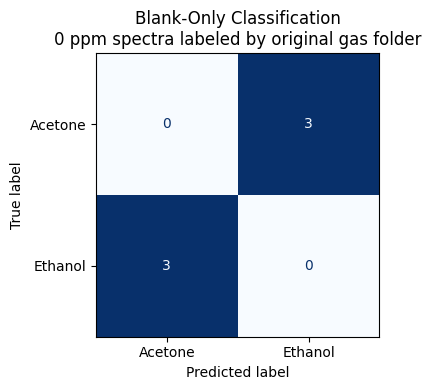


EXACT PERMUTATION TEST FOR BLANK-ONLY ACCURACY
Number of exact label permutations: 20
Observed blank-only accuracy:       0.0000
Permutation p-value:                1.0000

Permutation accuracy distribution:
0.0    20
Name: count, dtype: int64


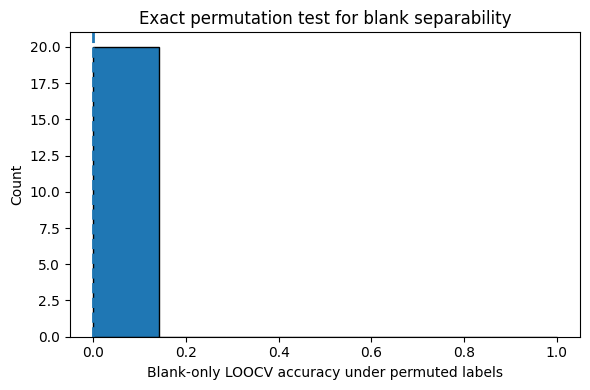


PCA VISUALIZATION OF BLANK SPECTRA
Blank PCA explained variance ratio:
PC1: 0.2240
PC2: 0.2062


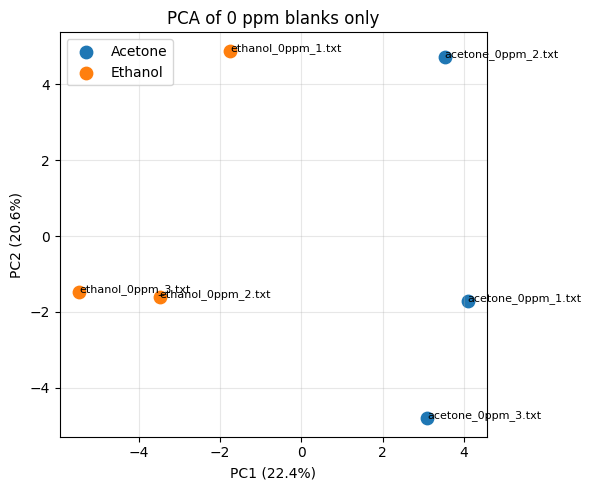


MEAN BLANK DIFFERENCE SPECTRUM


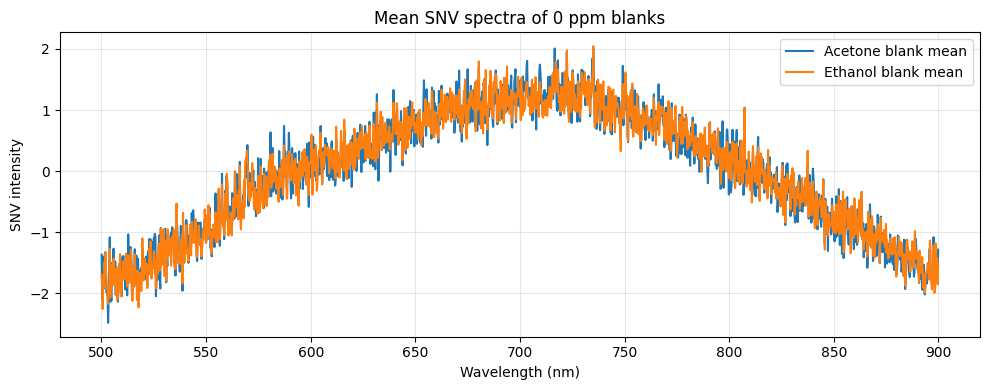

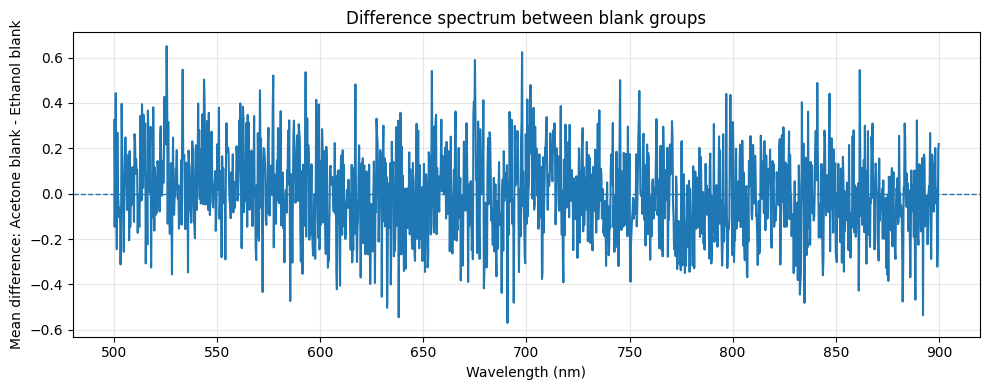

Top 20 wavelengths separating blank groups by absolute mean difference:


,Rank,Wavelength_nm,Mean_Acetone_Blank,Mean_Ethanol_Blank,Absolute_Mean_Difference
0,1,525.510,-1.027678,-1.678158,0.650480
1,2,697.886,1.666660,1.042578,0.624082
2,3,675.024,1.667097,1.077596,0.589501
3,4,690.781,0.904723,1.474060,0.569336
4,5,533.286,-1.000109,-1.546635,0.546527
5,6,861.630,-0.625709,-1.170747,0.545038
6,7,638.043,-0.009861,0.534538,0.544399
7,8,654.133,1.485638,0.944478,0.541161
8,9,592.915,0.137593,-0.398111,0.535704
9,10,892.292,-1.942139,-1.407257,0.534882


In [8]:
# ============================================================
# CELL 7: Blank-only separability audit
# Can 0 ppm blanks be classified by original gas folder?
#
# Rationale: if a classifier can tell "Ethanol's blank" apart from
# "Acetone's blank" above chance, that would mean some systematic,
# non-chemical difference (e.g. acquisition session, baseline drift)
# is leaking into the blank measurements themselves. This audit checks
# that possibility directly, with an exact (combinatorial) permutation
# test rather than the 500-sample Monte Carlo permutation used
# elsewhere, since the blank-only sample size is small enough to
# enumerate every possible label assignment exactly.
# ============================================================

from sklearn.model_selection import LeaveOneOut
from itertools import combinations
from math import comb

# ------------------------------------------------------------
# Extract blank-only dataset
# ------------------------------------------------------------
blank_mask = df_cls["Concentration"].values == 0

X_blank = X_baseline[blank_mask]
df_blank_eval = df_cls.loc[blank_mask].copy().reset_index(drop=True)

y_blank = df_blank_eval["Original_Gas_Label"].values

print("=" * 80)
print("BLANK-ONLY DATASET CHECK")
print("=" * 80)
print(f"N blank spectra: {len(df_blank_eval)}")
print("\nBlank label counts:")
print(pd.Series(y_blank).value_counts())

display(df_blank_eval[[
    "Original_Gas_Label",
    "Gas_ID_Label_With_Blank",
    "Concentration",
    "Filename"
]])

# ------------------------------------------------------------
# Only run classifier if at least 2 blank classes exist
# ------------------------------------------------------------
unique_blank_labels = sorted(pd.unique(y_blank))

if len(unique_blank_labels) < 2:
    print("\nOnly one blank class found. Blank-label classification is not possible.")
else:
    # --------------------------------------------------------
    # Leave-one-out classification on blank spectra only
    # RBF SVC mirrors the baseline model.
    # --------------------------------------------------------
    loo = LeaveOneOut()

    blank_oof_pred = np.empty(len(y_blank), dtype=object)

    for train_idx, test_idx in loo.split(X_blank):
        clf_blank = SVC(kernel="rbf", C=10, gamma="scale")
        clf_blank.fit(X_blank[train_idx], y_blank[train_idx])
        blank_oof_pred[test_idx] = clf_blank.predict(X_blank[test_idx])

    blank_acc = accuracy_score(y_blank, blank_oof_pred)
    blank_bal_acc = balanced_accuracy_score(y_blank, blank_oof_pred)

    print("\n" + "=" * 80)
    print("BLANK-ONLY CLASSIFICATION RESULT")
    print("=" * 80)
    print(f"Leave-one-out accuracy:          {blank_acc:.4f} ({blank_acc * 100:.2f}%)")
    print(f"Leave-one-out balanced accuracy: {blank_bal_acc:.4f} ({blank_bal_acc * 100:.2f}%)")

    print("\nBlank-only prediction table:")
    blank_pred_df = df_blank_eval[[
        "Original_Gas_Label",
        "Concentration",
        "Filename"
    ]].copy()
    blank_pred_df["Predicted_Original_Gas_Label"] = blank_oof_pred
    blank_pred_df["Correct"] = blank_pred_df["Original_Gas_Label"] == blank_pred_df["Predicted_Original_Gas_Label"]
    display(blank_pred_df)

    print("\nBlank-only classification report:")
    print(classification_report(y_blank, blank_oof_pred, labels=unique_blank_labels))

    cm_blank = confusion_matrix(y_blank, blank_oof_pred, labels=unique_blank_labels)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_blank,
        display_labels=unique_blank_labels
    )

    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    plt.title("Blank-Only Classification\n0 ppm spectra labeled by original gas folder")
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Exact permutation test for blank-only accuracy
    # Works cleanly for 2 classes with small n.
    #
    # Every possible way of assigning n_a samples to class_a (with the
    # remainder fixed to class_b) is enumerated via combinations(), so
    # the null distribution exactly preserves the original class
    # balance. The classifier is then re-fit and re-evaluated under
    # each shuffled labeling; p-value is the fraction of permuted
    # accuracies at least as extreme as the one observed with the
    # true labels.
    # --------------------------------------------------------
    print("\n" + "=" * 80)
    print("EXACT PERMUTATION TEST FOR BLANK-ONLY ACCURACY")
    print("=" * 80)

    observed_acc = blank_acc

    label_counts = pd.Series(y_blank).value_counts()
    if len(label_counts) == 2:
        class_a, class_b = label_counts.index.tolist()
        n_a = label_counts[class_a]
        n_total = len(y_blank)

        perm_accs = []

        # Generate all label assignments preserving class counts.
        for idx_a in combinations(range(n_total), n_a):
            y_perm = np.array([class_b] * n_total, dtype=object)
            y_perm[list(idx_a)] = class_a

            perm_pred = np.empty(n_total, dtype=object)

            for train_idx, test_idx in loo.split(X_blank):
                clf_perm = SVC(kernel="rbf", C=10, gamma="scale")
                clf_perm.fit(X_blank[train_idx], y_perm[train_idx])
                perm_pred[test_idx] = clf_perm.predict(X_blank[test_idx])

            perm_accs.append(accuracy_score(y_perm, perm_pred))

        perm_accs = np.array(perm_accs)
        p_value = np.mean(perm_accs >= observed_acc)

        print(f"Number of exact label permutations: {len(perm_accs)}")
        print(f"Observed blank-only accuracy:       {observed_acc:.4f}")
        print(f"Permutation p-value:                {p_value:.4f}")
        print("\nPermutation accuracy distribution:")
        print(pd.Series(perm_accs).value_counts().sort_index())

        plt.figure(figsize=(6, 4))
        plt.hist(perm_accs, bins=np.linspace(0, 1, 8), edgecolor="black")
        plt.axvline(observed_acc, linestyle="--", linewidth=2)
        plt.xlabel("Blank-only LOOCV accuracy under permuted labels")
        plt.ylabel("Count")
        plt.title("Exact permutation test for blank separability")
        plt.tight_layout()
        plt.show()
    else:
        print("Exact two-class permutation test skipped because blank labels are not exactly two classes.")

# ------------------------------------------------------------
# PCA visualization of blank spectra
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("PCA VISUALIZATION OF BLANK SPECTRA")
print("=" * 80)

if len(df_blank_eval) >= 3:
    pca_blank = PCA(n_components=2, random_state=RANDOM_STATE)
    blank_pca_scores = pca_blank.fit_transform(X_blank)

    pca_blank_df = df_blank_eval.copy()
    pca_blank_df["PC1"] = blank_pca_scores[:, 0]
    pca_blank_df["PC2"] = blank_pca_scores[:, 1]

    print("Blank PCA explained variance ratio:")
    print(f"PC1: {pca_blank.explained_variance_ratio_[0]:.4f}")
    print(f"PC2: {pca_blank.explained_variance_ratio_[1]:.4f}")

    plt.figure(figsize=(6, 5))

    for label in sorted(pca_blank_df["Original_Gas_Label"].unique()):
        temp = pca_blank_df[pca_blank_df["Original_Gas_Label"] == label]
        plt.scatter(temp["PC1"], temp["PC2"], label=label, s=80)

        for _, row in temp.iterrows():
            short_name = row["Filename"][:18]
            plt.text(row["PC1"], row["PC2"], short_name, fontsize=8)

    plt.xlabel(f"PC1 ({pca_blank.explained_variance_ratio_[0] * 100:.1f}%)")
    plt.ylabel(f"PC2 ({pca_blank.explained_variance_ratio_[1] * 100:.1f}%)")
    plt.title("PCA of 0 ppm blanks only")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough blank samples for PCA.")

# ------------------------------------------------------------
# Mean blank spectra and difference spectrum
# Only meaningful for 2 blank groups.
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("MEAN BLANK DIFFERENCE SPECTRUM")
print("=" * 80)

if len(unique_blank_labels) == 2:
    label_a, label_b = unique_blank_labels

    Xa = X_blank[y_blank == label_a]
    Xb = X_blank[y_blank == label_b]

    mean_a = Xa.mean(axis=0)
    mean_b = Xb.mean(axis=0)
    diff_ab = mean_a - mean_b

    plt.figure(figsize=(10, 4))
    plt.plot(wl_baseline, mean_a, label=f"{label_a} blank mean")
    plt.plot(wl_baseline, mean_b, label=f"{label_b} blank mean")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("SNV intensity")
    plt.title("Mean SNV spectra of 0 ppm blanks")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(wl_baseline, diff_ab)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xlabel("Wavelength (nm)")
    plt.ylabel(f"Mean difference: {label_a} blank - {label_b} blank")
    plt.title("Difference spectrum between blank groups")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    top_diff_idx = np.argsort(np.abs(diff_ab))[::-1][:20]

    top_blank_diff_df = pd.DataFrame({
        "Rank": np.arange(1, len(top_diff_idx) + 1),
        "Wavelength_nm": wl_baseline[top_diff_idx],
        f"Mean_{label_a}_Blank": mean_a[top_diff_idx],
        f"Mean_{label_b}_Blank": mean_b[top_diff_idx],
        "Absolute_Mean_Difference": np.abs(diff_ab[top_diff_idx])
    })

    print("Top 20 wavelengths separating blank groups by absolute mean difference:")
    display(top_blank_diff_df)
else:
    print("Mean difference spectrum skipped because blank labels are not exactly two classes.")

ROBUST BLANK SEPARABILITY AUDIT
N blank spectra: 6
Blank labels: ['Acetone', 'Ethanol']
Ethanol    3
Acetone    3
Name: count, dtype: int64

Blank-only model comparison:


,Model,LOOCV_Accuracy,Label_Swapped_Accuracy,Separability_Score_max_acc_or_swapped
0,RBF_SVC_C10,0.000000,1.000000,1.000000
1,Linear_SVC_C1,0.166667,0.833333,0.833333
2,LogisticRegression,0.000000,1.000000,1.000000
3,1NN_Euclidean,0.833333,0.166667,0.833333
4,3NN_Euclidean,1.000000,0.000000,1.000000



RBF SVC blank prediction table:


,Original_Gas_Label,Concentration,Filename,Predicted,Correct
0,Ethanol,0.0,ethanol_0ppm_1.txt,Acetone,False
1,Ethanol,0.0,ethanol_0ppm_2.txt,Acetone,False
2,Ethanol,0.0,ethanol_0ppm_3.txt,Acetone,False
3,Acetone,0.0,acetone_0ppm_1.txt,Ethanol,False
4,Acetone,0.0,acetone_0ppm_2.txt,Ethanol,False
5,Acetone,0.0,acetone_0ppm_3.txt,Ethanol,False



EXACT PERMUTATION TEST USING SEPARABILITY SCORE
Observed RBF SVC accuracy:            0.0000
Observed separability score:          1.0000
Exact permutations:                   20
Permutation p-value, separability:    1.0000

Permutation separability distribution:


1.0    20
Name: count, dtype: int64

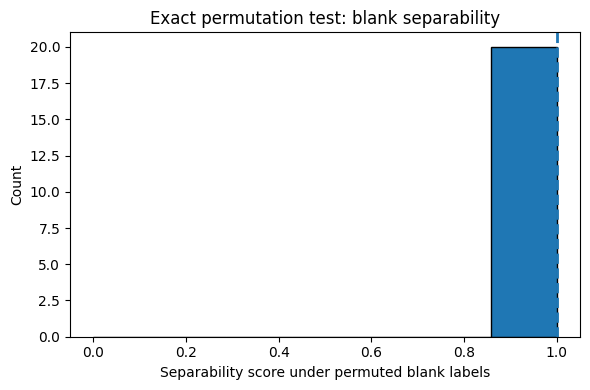


PAIRWISE DISTANCE AUDIT
Pairwise Euclidean distance matrix between blank spectra:


,Ethanol_1,Ethanol_2,Ethanol_3,Acetone_4,Acetone_5,Acetone_6
Ethanol_1,0.000000,12.089683,11.890259,12.398722,11.904170,12.376300
Ethanol_2,12.089683,0.000000,11.714396,12.310747,12.218960,12.327918
Ethanol_3,11.890259,11.714396,0.000000,12.483769,12.540124,12.403419
Acetone_4,12.398722,12.310747,12.483769,0.000000,12.150930,12.337890
Acetone_5,11.904170,12.218960,12.540124,12.150930,0.000000,12.204903
Acetone_6,12.376300,12.327918,12.403419,12.337890,12.204903,0.000000



Within-label vs between-label blank distances:


,Same_Original_Gas_Label,N,Mean_Distance,Median_Distance,Min_Distance,Max_Distance
0,False,9,12.329348,12.376300,11.904170,12.540124
1,True,6,12.064677,12.120307,11.714396,12.337890



Nearest-neighbor audit:


,Sample,Original_Gas_Label,Nearest_Blank,Nearest_Blank_Label,Nearest_Distance,Nearest_Has_Same_Label
0,ethanol_0ppm_1.txt,Ethanol,ethanol_0ppm_3.txt,Ethanol,11.890259,True
1,ethanol_0ppm_2.txt,Ethanol,ethanol_0ppm_3.txt,Ethanol,11.714396,True
2,ethanol_0ppm_3.txt,Ethanol,ethanol_0ppm_2.txt,Ethanol,11.714396,True
3,acetone_0ppm_1.txt,Acetone,acetone_0ppm_2.txt,Acetone,12.150930,True
4,acetone_0ppm_2.txt,Acetone,ethanol_0ppm_1.txt,Ethanol,11.904170,False
5,acetone_0ppm_3.txt,Acetone,acetone_0ppm_2.txt,Acetone,12.204903,True



Nearest neighbor same-label rate:
0.8333333333333334

BLANK PCA WITH LABELS
PC1 explained variance: 0.2240
PC2 explained variance: 0.2062


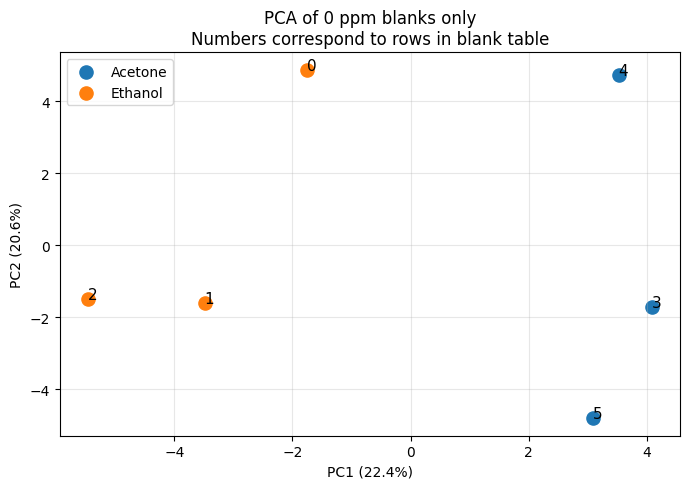


Blank PCA table:


,Original_Gas_Label,Filename,PC1,PC2
0,Ethanol,ethanol_0ppm_1.txt,-1.751401,4.885352
1,Ethanol,ethanol_0ppm_2.txt,-3.485359,-1.610828
2,Ethanol,ethanol_0ppm_3.txt,-5.462500,-1.488126
3,Acetone,acetone_0ppm_1.txt,4.083928,-1.707789
4,Acetone,acetone_0ppm_2.txt,3.522418,4.727839
5,Acetone,acetone_0ppm_3.txt,3.092915,-4.806449


In [9]:
# ============================================================
# CELL 8: Robust blank separability audit
# 0% and 100% are both suspicious in a two-class blank test.
#
# Extends Cell 7 with multiple classifier families (not just RBF SVC),
# a label-swap-aware separability score, and a pairwise-distance /
# nearest-neighbor audit, to triangulate whether the blanks carry any
# systematic, non-chemical signal.
# ============================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import pairwise_distances
from itertools import combinations

print("=" * 80)
print("ROBUST BLANK SEPARABILITY AUDIT")
print("=" * 80)

# Reuse blank data from Cell 7
X_blank = X_baseline[blank_mask]
df_blank_eval = df_cls.loc[blank_mask].copy().reset_index(drop=True)
y_blank = df_blank_eval["Original_Gas_Label"].values

unique_blank_labels = sorted(pd.unique(y_blank))

print(f"N blank spectra: {len(y_blank)}")
print("Blank labels:", unique_blank_labels)
print(pd.Series(y_blank).value_counts())

assert len(unique_blank_labels) == 2, "This robust audit assumes exactly two blank groups."

label_a, label_b = unique_blank_labels

# ------------------------------------------------------------
# Helper: LOOCV evaluator for small blank dataset
# ------------------------------------------------------------

def loocv_predict_small_model(model, X, y):
    """Leave-one-out out-of-fold predictions for a small dataset."""
    loo = LeaveOneOut()
    pred = np.empty(len(y), dtype=object)

    for train_idx, test_idx in loo.split(X):
        model.fit(X[train_idx], y[train_idx])
        pred[test_idx] = model.predict(X[test_idx])

    return pred


blank_models = {
    "RBF_SVC_C10": SVC(kernel="rbf", C=10, gamma="scale"),
    "Linear_SVC_C1": SVC(kernel="linear", C=1),
    "LogisticRegression": LogisticRegression(max_iter=5000, solver="liblinear"),
    "1NN_Euclidean": KNeighborsClassifier(n_neighbors=1, metric="euclidean"),
    "3NN_Euclidean": KNeighborsClassifier(n_neighbors=3, metric="euclidean")
}

blank_model_rows = []
blank_prediction_tables = {}

for model_name, model in blank_models.items():
    pred = loocv_predict_small_model(model, X_blank, y_blank)

    acc = accuracy_score(y_blank, pred)

    # For two-class labels, complete label reversal is also separability:
    # an accuracy near 0% means the classifier is consistently confident
    # but inverted, which is just as informative as accuracy near 100%.
    # Taking the max of the two treats both extremes as equally suspicious.
    anti_acc = 1.0 - acc
    separability_score = max(acc, anti_acc)

    blank_model_rows.append({
        "Model": model_name,
        "LOOCV_Accuracy": acc,
        "Label_Swapped_Accuracy": anti_acc,
        "Separability_Score_max_acc_or_swapped": separability_score
    })

    temp = df_blank_eval[[
        "Original_Gas_Label",
        "Concentration",
        "Filename"
    ]].copy()
    temp["Predicted"] = pred
    temp["Correct"] = temp["Original_Gas_Label"] == temp["Predicted"]
    blank_prediction_tables[model_name] = temp

blank_model_df = pd.DataFrame(blank_model_rows)

print("\nBlank-only model comparison:")
display(blank_model_df)

print("\nRBF SVC blank prediction table:")
display(blank_prediction_tables["RBF_SVC_C10"])

# ------------------------------------------------------------
# Exact permutation test using separability score
# This treats 0% and 100% as equally extreme for two classes.
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("EXACT PERMUTATION TEST USING SEPARABILITY SCORE")
print("=" * 80)

observed_pred = blank_prediction_tables["RBF_SVC_C10"]["Predicted"].values
observed_acc = accuracy_score(y_blank, observed_pred)
observed_sep = max(observed_acc, 1.0 - observed_acc)

label_counts = pd.Series(y_blank).value_counts()
class_a, class_b = label_counts.index.tolist()
n_a = label_counts[class_a]
n_total = len(y_blank)

perm_sep_scores = []
perm_accs = []

for idx_a in combinations(range(n_total), n_a):
    y_perm = np.array([class_b] * n_total, dtype=object)
    y_perm[list(idx_a)] = class_a

    pred_perm = loocv_predict_small_model(
        SVC(kernel="rbf", C=10, gamma="scale"),
        X_blank,
        y_perm
    )

    acc_perm = accuracy_score(y_perm, pred_perm)
    sep_perm = max(acc_perm, 1.0 - acc_perm)

    perm_accs.append(acc_perm)
    perm_sep_scores.append(sep_perm)

perm_accs = np.array(perm_accs)
perm_sep_scores = np.array(perm_sep_scores)

p_sep = np.mean(perm_sep_scores >= observed_sep)

print(f"Observed RBF SVC accuracy:            {observed_acc:.4f}")
print(f"Observed separability score:          {observed_sep:.4f}")
print(f"Exact permutations:                   {len(perm_sep_scores)}")
print(f"Permutation p-value, separability:    {p_sep:.4f}")

print("\nPermutation separability distribution:")
display(pd.Series(perm_sep_scores).value_counts().sort_index())

plt.figure(figsize=(6, 4))
plt.hist(perm_sep_scores, bins=np.linspace(0, 1, 8), edgecolor="black")
plt.axvline(observed_sep, linestyle="--", linewidth=2)
plt.xlabel("Separability score under permuted blank labels")
plt.ylabel("Count")
plt.title("Exact permutation test: blank separability")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Pairwise distance matrix
# If blanks are true shared blanks, within/between distances
# should not show strong gas-folder structure.
#
# i.e. if 0 ppm spectra are genuinely just "no gas present," distances
# between blanks from different gas folders should look similar to
# distances within the same folder. A systematic gap would indicate a
# non-chemical (e.g. session-level) artifact rather than true blank
# equivalence.
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("PAIRWISE DISTANCE AUDIT")
print("=" * 80)

D = pairwise_distances(X_blank, metric="euclidean")

distance_df = pd.DataFrame(
    D,
    index=[
        f"{row.Original_Gas_Label}_{i+1}"
        for i, row in df_blank_eval.iterrows()
    ],
    columns=[
        f"{row.Original_Gas_Label}_{i+1}"
        for i, row in df_blank_eval.iterrows()
    ]
)

print("Pairwise Euclidean distance matrix between blank spectra:")
display(distance_df)

distance_rows = []

for i in range(len(y_blank)):
    for j in range(i + 1, len(y_blank)):
        distance_rows.append({
            "Sample_i": df_blank_eval.loc[i, "Filename"],
            "Sample_j": df_blank_eval.loc[j, "Filename"],
            "Label_i": y_blank[i],
            "Label_j": y_blank[j],
            "Same_Original_Gas_Label": y_blank[i] == y_blank[j],
            "Distance": D[i, j]
        })

pairwise_long_df = pd.DataFrame(distance_rows)

print("\nWithin-label vs between-label blank distances:")
display(
    pairwise_long_df
    .groupby("Same_Original_Gas_Label")
    .agg(
        N=("Distance", "size"),
        Mean_Distance=("Distance", "mean"),
        Median_Distance=("Distance", "median"),
        Min_Distance=("Distance", "min"),
        Max_Distance=("Distance", "max")
    )
    .reset_index()
)

# ------------------------------------------------------------
# Nearest-neighbor identity audit
#
# For each blank spectrum, finds its closest other blank and checks
# whether it shares the same original-gas-folder label. A high
# same-label rate would corroborate the pairwise-distance finding above
# that blanks cluster by folder rather than behaving as interchangeable
# "no gas" measurements.
# ------------------------------------------------------------

nn_rows = []

for i in range(len(y_blank)):
    distances = D[i].copy()
    distances[i] = np.inf

    nearest_idx = np.argmin(distances)

    nn_rows.append({
        "Sample": df_blank_eval.loc[i, "Filename"],
        "Original_Gas_Label": y_blank[i],
        "Nearest_Blank": df_blank_eval.loc[nearest_idx, "Filename"],
        "Nearest_Blank_Label": y_blank[nearest_idx],
        "Nearest_Distance": distances[nearest_idx],
        "Nearest_Has_Same_Label": y_blank[i] == y_blank[nearest_idx]
    })

nn_df = pd.DataFrame(nn_rows)

print("\nNearest-neighbor audit:")
display(nn_df)

print("\nNearest neighbor same-label rate:")
print(nn_df["Nearest_Has_Same_Label"].mean())

# ------------------------------------------------------------
# PCA plot with sample numbers
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("BLANK PCA WITH LABELS")
print("=" * 80)

pca_blank = PCA(n_components=2, random_state=RANDOM_STATE)
blank_pca_scores = pca_blank.fit_transform(X_blank)

pca_blank_df = df_blank_eval.copy()
pca_blank_df["PC1"] = blank_pca_scores[:, 0]
pca_blank_df["PC2"] = blank_pca_scores[:, 1]

print(f"PC1 explained variance: {pca_blank.explained_variance_ratio_[0]:.4f}")
print(f"PC2 explained variance: {pca_blank.explained_variance_ratio_[1]:.4f}")

plt.figure(figsize=(7, 5))

for label in unique_blank_labels:
    temp = pca_blank_df[pca_blank_df["Original_Gas_Label"] == label]
    plt.scatter(temp["PC1"], temp["PC2"], s=90, label=label)

    for idx, row in temp.iterrows():
        plt.text(row["PC1"], row["PC2"], str(idx), fontsize=11)

plt.xlabel(f"PC1 ({pca_blank.explained_variance_ratio_[0] * 100:.1f}%)")
plt.ylabel(f"PC2 ({pca_blank.explained_variance_ratio_[1] * 100:.1f}%)")
plt.title("PCA of 0 ppm blanks only\nNumbers correspond to rows in blank table")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nBlank PCA table:")
display(pca_blank_df[[
    "Original_Gas_Label",
    "Filename",
    "PC1",
    "PC2"
]])

In [10]:
# ============================================================
# CELL 9: Extract replicate ID / acquisition surrogate groups
#
# Replicate_ID (1, 2, or 3) stands in for "which acquisition session a
# spectrum came from," since true independent acquisition sessions
# were not collected. Holding out one replicate at a time (Cells 10
# and 13) gives a second, complementary leakage-robustness check
# alongside the primary concentration-holdout split: it tests whether
# performance depends on session-specific artifacts rather than
# concentration-specific ones.
# ============================================================

def extract_replicate_id(filename):
    """
    Extract final replicate number from filenames like:
    ethanol_0ppm_1.txt
    acetone_20ppm_3.txt

    Returns NaN if not found.
    """
    base = os.path.basename(filename).replace(".txt", "")

    # Last underscore-separated numeric token
    match = re.search(r"_([0-9]+)$", base)
    if match:
        return int(match.group(1))

    return np.nan


df_cls["Replicate_ID"] = df_cls["Filename"].apply(extract_replicate_id)

# For safety, recreate nonzero version after adding Replicate_ID
df_nonzero = df_cls[df_cls["Concentration"] > 0].copy().reset_index(drop=True)

print("=" * 80)
print("REPLICATE / ACQUISITION SURROGATE AUDIT")
print("=" * 80)

print("Replicate ID counts, full dataset:")
print(df_cls["Replicate_ID"].value_counts(dropna=False).sort_index())

print("\nReplicate ID counts, nonzero-only dataset:")
print(df_nonzero["Replicate_ID"].value_counts(dropna=False).sort_index())

print("\nGas x Replicate_ID table, nonzero-only:")
display(
    pd.crosstab(
        df_nonzero["Original_Gas_Label"],
        df_nonzero["Replicate_ID"],
        margins=True
    )
)

print("\nConcentration x Replicate_ID table, nonzero-only:")
display(
    pd.crosstab(
        df_nonzero["Concentration"],
        df_nonzero["Replicate_ID"],
        margins=True
    )
)

print("\nRows with missing Replicate_ID:")
display(
    df_cls[df_cls["Replicate_ID"].isna()][
        ["Original_Gas_Label", "Concentration", "Filename"]
    ]
)

assert df_cls["Replicate_ID"].notna().all(), "Some files do not have parseable replicate IDs."

print("\nReplicate metadata created successfully.")

REPLICATE / ACQUISITION SURROGATE AUDIT
Replicate ID counts, full dataset:
Replicate_ID
1    46
2    46
3    46
Name: count, dtype: int64

Replicate ID counts, nonzero-only dataset:
Replicate_ID
1    44
2    44
3    44
Name: count, dtype: int64

Gas x Replicate_ID table, nonzero-only:


Replicate_ID,1,2,3,All
Original_Gas_Label,,,,
Acetone,15,15,15,45
Ammonia,14,14,14,42
Ethanol,15,15,15,45
All,44,44,44,132



Concentration x Replicate_ID table, nonzero-only:


Replicate_ID,1,2,3,All
Concentration,,,,
1.0,2,2,2,6
2.0,3,3,3,9
3.0,2,2,2,6
4.0,3,3,3,9
5.0,2,2,2,6
6.0,1,1,1,3
8.0,1,1,1,3
10.0,3,3,3,9
12.0,1,1,1,3



Rows with missing Replicate_ID:


,Original_Gas_Label,Concentration,Filename



Replicate metadata created successfully.


Acquisition-Surrogate Holdout: Nonzero Gas ID
Fixed 500–900 nm + SNV + RBF SVC + Leave-One-Replicate-Out
N spectra:          132
N groups:           3
Groups:             [np.int64(1), np.int64(2), np.int64(3)]
Accuracy:           0.9773  (97.73%)
Balanced accuracy:  0.9778  (97.78%)
Macro F1:           0.9778
Weighted F1:        0.9772

Fold-level results:


,Fold,Heldout_Replicate_ID,N_Test,Classes_In_Test,Accuracy,Balanced_Accuracy
0,1,1,44,"Acetone, Ammonia, Ethanol",0.977273,0.977778
1,2,2,44,"Acetone, Ammonia, Ethanol",1.000000,1.000000
2,3,3,44,"Acetone, Ammonia, Ethanol",0.954545,0.955556



Classification report:
              precision    recall  f1-score   support

     Ethanol       1.00      0.93      0.97        45
     Acetone       0.94      1.00      0.97        45
     Ammonia       1.00      1.00      1.00        42

    accuracy                           0.98       132
   macro avg       0.98      0.98      0.98       132
weighted avg       0.98      0.98      0.98       132


Per-Replicate_ID accuracy:


,Replicate_ID,N,Accuracy
0,1,44,0.977273
1,2,44,1.000000
2,3,44,0.954545


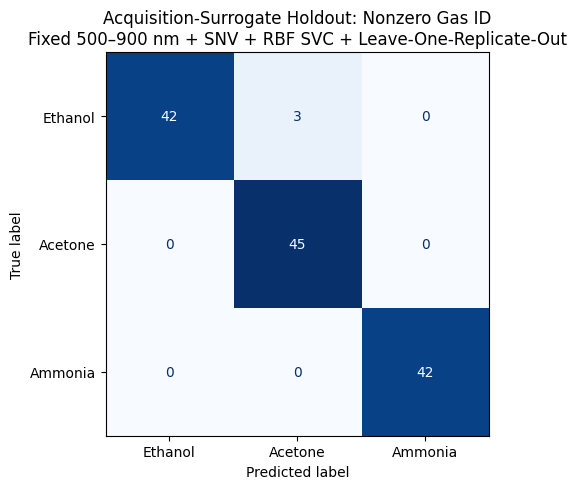


Leave-one-replicate-out prediction table:


,Original_Gas_Label,Concentration,Replicate_ID,Filename,OOF_Predicted_Label,Correct
0,Ethanol,100.0,1,ethanol_100ppm_1.txt,Ethanol,True
1,Ethanol,100.0,2,ethanol_100ppm_2.txt,Ethanol,True
2,Ethanol,100.0,3,ethanol_100ppm_3.txt,Ethanol,True
3,Ethanol,10.0,1,ethanol_10ppm_1.txt,Ethanol,True
4,Ethanol,10.0,2,ethanol_10ppm_2.txt,Ethanol,True
5,Ethanol,10.0,3,ethanol_10ppm_3.txt,Ethanol,True
6,Ethanol,1.0,1,ethanol_1ppm_1.txt,Ethanol,True
7,Ethanol,1.0,2,ethanol_1ppm_2.txt,Ethanol,True
8,Ethanol,1.0,3,ethanol_1ppm_3.txt,Ethanol,True
9,Ethanol,20.0,1,ethanol_20ppm_1.txt,Ethanol,True



Accuracy by gas and replicate:


,Original_Gas_Label,Replicate_ID,N,Accuracy
0,Acetone,1,15,1.000000
1,Acetone,2,15,1.000000
2,Acetone,3,15,1.000000
3,Ammonia,1,14,1.000000
4,Ammonia,2,14,1.000000
5,Ammonia,3,14,1.000000
6,Ethanol,1,15,0.933333
7,Ethanol,2,15,1.000000
8,Ethanol,3,15,0.866667



Errors only:


,Original_Gas_Label,Concentration,Replicate_ID,Filename,OOF_Predicted_Label
14,Ethanol,2.0,3,ethanol_2ppm_3.txt,Acetone
20,Ethanol,3.0,3,ethanol_3ppm_3.txt,Acetone
30,Ethanol,5.0,1,ethanol_5ppm_1.txt,Acetone


In [11]:
# ============================================================
# CELL 10: Leave-one-replicate-out gas-ID baseline
# Fixed 500–900 nm + SNV + RBF SVC
# Nonzero spectra only
#
# Same fixed pipeline as Cell 6, but grouped by Replicate_ID instead of
# Concentration. Serves strictly as a measurement-block consistency
# check (see paper Table 9 "Acquisition-surrogate"), not as a stand-in
# for true external validation.
# ============================================================

# Nonzero mask aligned to full df_cls / X_baseline
nonzero_mask = df_cls["Concentration"].values > 0

X_nonzero_baseline = X_baseline[nonzero_mask]
df_nonzero_eval = df_cls.loc[nonzero_mask].copy().reset_index(drop=True)

labels_order_gases = ["Ethanol", "Acetone", "Ammonia"]

replicate_pred_df, replicate_fold_df, replicate_metrics = evaluate_logo_svc(
    X=X_nonzero_baseline,
    df_eval=df_nonzero_eval,
    y_col="Original_Gas_Label",
    group_col="Replicate_ID",
    labels_order=labels_order_gases,
    title="Acquisition-Surrogate Holdout: Nonzero Gas ID\nFixed 500–900 nm + SNV + RBF SVC + Leave-One-Replicate-Out",
    kernel="rbf",
    C=10,
    gamma="scale"
)

print("\nLeave-one-replicate-out prediction table:")
display(
    replicate_pred_df[[
        "Original_Gas_Label",
        "Concentration",
        "Replicate_ID",
        "Filename",
        "OOF_Predicted_Label",
        "Correct"
    ]].head(20)
)

print("\nAccuracy by gas and replicate:")
display(
    replicate_pred_df
    .groupby(["Original_Gas_Label", "Replicate_ID"])
    .agg(
        N=("Correct", "size"),
        Accuracy=("Correct", "mean")
    )
    .reset_index()
)

print("\nErrors only:")
display(
    replicate_pred_df.loc[
        ~replicate_pred_df["Correct"],
        [
            "Original_Gas_Label",
            "Concentration",
            "Replicate_ID",
            "Filename",
            "OOF_Predicted_Label"
        ]
    ].sort_values(["Original_Gas_Label", "Concentration", "Replicate_ID"])
)

In [12]:
# ============================================================
# CELL 11: Candidate preprocessing functions for nested CV
#
# Defines the inner-loop search space used by Cells 12, 13, and 15:
# a small grid of (wavelength window, preprocessing, kernel, C, gamma)
# combinations. In the nested CV cells below, candidates are scored
# using only the outer-training data (never the held-out outer-test
# fold), so the model-selection step itself cannot leak information
# about the held-out concentration/replicate.
# ============================================================

def preprocess_raw(X):
    """Identity preprocessing: return an unmodified copy of X."""
    return X.copy()

def preprocess_snv(X):
    """Row-wise Standard Normal Variate (thin wrapper around snv_transform)."""
    return snv_transform(X)

def preprocess_snv_savgol(X, window_length=15, polyorder=2):
    """
    SNV followed by Savitzky-Golay smoothing.
    Window length must be odd and <= number of wavelengths.
    """
    X_snv = snv_transform(X)

    if window_length >= X_snv.shape[1]:
        window_length = X_snv.shape[1] - 1
        if window_length % 2 == 0:
            window_length -= 1

    if window_length < 5:
        return X_snv

    return savgol_filter(
        X_snv,
        window_length=window_length,
        polyorder=polyorder,
        axis=1
    )

def preprocess_snv_derivative1(X, window_length=15, polyorder=2):
    """
    SNV followed by first derivative using Savitzky-Golay.
    """
    X_snv = snv_transform(X)

    if window_length >= X_snv.shape[1]:
        window_length = X_snv.shape[1] - 1
        if window_length % 2 == 0:
            window_length -= 1

    if window_length < 5:
        return X_snv

    return savgol_filter(
        X_snv,
        window_length=window_length,
        polyorder=polyorder,
        deriv=1,
        axis=1
    )


def apply_candidate_preprocessing(X_raw_input, wavelengths, wl_min, wl_max, preprocess_name):
    """
    Apply wavelength crop and selected preprocessing.
    """
    wl_mask = (wavelengths >= wl_min) & (wavelengths <= wl_max)
    X_crop = X_raw_input[:, wl_mask]
    wl_active = wavelengths[wl_mask]

    if preprocess_name == "raw":
        X_proc = preprocess_raw(X_crop)
    elif preprocess_name == "snv":
        X_proc = preprocess_snv(X_crop)
    elif preprocess_name == "snv_savgol":
        X_proc = preprocess_snv_savgol(X_crop)
    elif preprocess_name == "snv_derivative1":
        X_proc = preprocess_snv_derivative1(X_crop)
    else:
        raise ValueError(f"Unknown preprocessing option: {preprocess_name}")

    return X_proc, wl_active, wl_mask


# ------------------------------------------------------------
# Candidate search space
# Keep this moderate first. We can expand later.
# ------------------------------------------------------------
preprocess_candidates = [
    {
        "Candidate_ID": "500_900_snv_rbf_C10",
        "WL_Min": 500,
        "WL_Max": 900,
        "Preprocess": "snv",
        "Kernel": "rbf",
        "C": 10,
        "Gamma": "scale"
    },
    {
        "Candidate_ID": "500_900_snv_linear_C1",
        "WL_Min": 500,
        "WL_Max": 900,
        "Preprocess": "snv",
        "Kernel": "linear",
        "C": 1,
        "Gamma": "scale"
    },
    {
        "Candidate_ID": "400_900_snv_rbf_C10",
        "WL_Min": 400,
        "WL_Max": 900,
        "Preprocess": "snv",
        "Kernel": "rbf",
        "C": 10,
        "Gamma": "scale"
    },
    {
        "Candidate_ID": "500_1000_snv_rbf_C10",
        "WL_Min": 500,
        "WL_Max": 1000,
        "Preprocess": "snv",
        "Kernel": "rbf",
        "C": 10,
        "Gamma": "scale"
    },
    {
        "Candidate_ID": "500_900_raw_rbf_C10",
        "WL_Min": 500,
        "WL_Max": 900,
        "Preprocess": "raw",
        "Kernel": "rbf",
        "C": 10,
        "Gamma": "scale"
    },
    {
        "Candidate_ID": "500_900_snv_savgol_rbf_C10",
        "WL_Min": 500,
        "WL_Max": 900,
        "Preprocess": "snv_savgol",
        "Kernel": "rbf",
        "C": 10,
        "Gamma": "scale"
    },
    {
        "Candidate_ID": "500_900_snv_deriv1_rbf_C10",
        "WL_Min": 500,
        "WL_Max": 900,
        "Preprocess": "snv_derivative1",
        "Kernel": "rbf",
        "C": 10,
        "Gamma": "scale"
    },
    {
        "Candidate_ID": "600_900_snv_rbf_C10",
        "WL_Min": 600,
        "WL_Max": 900,
        "Preprocess": "snv",
        "Kernel": "rbf",
        "C": 10,
        "Gamma": "scale"
    }
]

candidate_df = pd.DataFrame(preprocess_candidates)

print("=" * 80)
print("CLASSIFICATION NESTED-CV CANDIDATE SPACE")
print("=" * 80)
display(candidate_df)

print(f"Number of candidate pipelines: {len(preprocess_candidates)}")
print("\nCandidate preprocessing functions ready.")

CLASSIFICATION NESTED-CV CANDIDATE SPACE


,Candidate_ID,WL_Min,WL_Max,Preprocess,Kernel,C,Gamma
0,500_900_snv_rbf_C10,500,900,snv,rbf,10,scale
1,500_900_snv_linear_C1,500,900,snv,linear,1,scale
2,400_900_snv_rbf_C10,400,900,snv,rbf,10,scale
3,500_1000_snv_rbf_C10,500,1000,snv,rbf,10,scale
4,500_900_raw_rbf_C10,500,900,raw,rbf,10,scale
5,500_900_snv_savgol_rbf_C10,500,900,snv_savgol,rbf,10,scale
6,500_900_snv_deriv1_rbf_C10,500,900,snv_derivative1,rbf,10,scale
7,600_900_snv_rbf_C10,600,900,snv,rbf,10,scale


Number of candidate pipelines: 8

Candidate preprocessing functions ready.


NESTED CV CLASSIFICATION STARTED
N spectra: 132
N classes: 3
Classes: ['Acetone', 'Ammonia', 'Ethanol']
N outer concentration folds: 23
N candidate pipelines: 8

Outer fold 01 / 23: held-out concentration = 1.0 ppm
  Selected: 500_900_snv_rbf_C10 | Inner mean bal acc = 0.9571

Outer fold 02 / 23: held-out concentration = 2.0 ppm
  Selected: 600_900_snv_rbf_C10 | Inner mean bal acc = 0.9722

Outer fold 03 / 23: held-out concentration = 3.0 ppm
  Selected: 500_900_snv_rbf_C10 | Inner mean bal acc = 0.9722

Outer fold 04 / 23: held-out concentration = 4.0 ppm
  Selected: 600_900_snv_rbf_C10 | Inner mean bal acc = 0.9545

Outer fold 05 / 23: held-out concentration = 5.0 ppm
  Selected: 600_900_snv_rbf_C10 | Inner mean bal acc = 0.9747

Outer fold 06 / 23: held-out concentration = 6.0 ppm
  Selected: 600_900_snv_rbf_C10 | Inner mean bal acc = 0.9596

Outer fold 07 / 23: held-out concentration = 8.0 ppm
  Selected: 600_900_snv_rbf_C10 | Inner mean bal acc = 0.9596

Outer fold 08 / 23: held-o

,Outer_Fold,Heldout_Concentration,N_Test,Classes_In_Test,Selected_Candidate_ID,Selected_WL_Min,Selected_WL_Max,Selected_Preprocess,Selected_Kernel,Selected_C,Selected_Gamma,Best_Inner_Mean_Balanced_Accuracy,Outer_Accuracy,Outer_Balanced_Accuracy
0,1,1.0,6,"Acetone, Ethanol",500_900_snv_rbf_C10,500,900,snv,rbf,10,scale,0.957071,0.666667,0.666667
1,2,2.0,9,"Acetone, Ammonia, Ethanol",600_900_snv_rbf_C10,600,900,snv,rbf,10,scale,0.972222,0.888889,0.888889
2,3,3.0,6,"Acetone, Ethanol",500_900_snv_rbf_C10,500,900,snv,rbf,10,scale,0.972222,0.833333,0.833333
3,4,4.0,9,"Acetone, Ammonia, Ethanol",600_900_snv_rbf_C10,600,900,snv,rbf,10,scale,0.954545,0.888889,0.888889
4,5,5.0,6,"Acetone, Ethanol",600_900_snv_rbf_C10,600,900,snv,rbf,10,scale,0.974747,0.666667,0.666667
5,6,6.0,3,Ammonia,600_900_snv_rbf_C10,600,900,snv,rbf,10,scale,0.959596,1.000000,1.000000
6,7,8.0,3,Ammonia,600_900_snv_rbf_C10,600,900,snv,rbf,10,scale,0.959596,1.000000,1.000000
7,8,10.0,9,"Acetone, Ammonia, Ethanol",500_900_snv_savgol_rbf_C10,500,900,snv_savgol,rbf,10,scale,0.944444,0.888889,0.888889
8,9,12.0,3,Ammonia,600_900_snv_rbf_C10,600,900,snv,rbf,10,scale,0.959596,1.000000,1.000000
9,10,14.0,3,Ammonia,600_900_snv_rbf_C10,600,900,snv,rbf,10,scale,0.959596,1.000000,1.000000



Selected candidate counts:


,Candidate_ID,Selected_Count
0,600_900_snv_rbf_C10,17
1,500_900_snv_rbf_C10,5
2,500_900_snv_savgol_rbf_C10,1



Selected preprocessing counts:


,Preprocess,Selected_Count
0,snv,22
1,snv_savgol,1



Per-concentration nested accuracy:


,Concentration,N,Accuracy
0,1.0,6,0.666667
1,2.0,9,0.888889
2,3.0,6,0.833333
3,4.0,9,0.888889
4,5.0,6,0.666667
5,6.0,3,1.000000
6,8.0,3,1.000000
7,10.0,9,0.888889
8,12.0,3,1.000000
9,14.0,3,1.000000


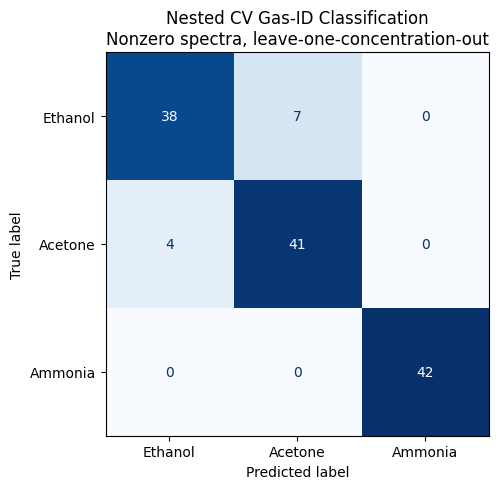


Errors only:


,Original_Gas_Label,Concentration,Replicate_ID,Filename,Nested_OOF_Predicted_Label
75,Acetone,5.0,1,acetone_5ppm_1.txt,Ethanol
80,Acetone,60.0,3,acetone_60ppm_3.txt,Ethanol
85,Acetone,80.0,2,acetone_80ppm_2.txt,Ethanol
88,Acetone,90.0,2,acetone_90ppm_2.txt,Ethanol
6,Ethanol,1.0,1,ethanol_1ppm_1.txt,Acetone
7,Ethanol,1.0,2,ethanol_1ppm_2.txt,Acetone
14,Ethanol,2.0,3,ethanol_2ppm_3.txt,Acetone
20,Ethanol,3.0,3,ethanol_3ppm_3.txt,Acetone
26,Ethanol,4.0,3,ethanol_4ppm_3.txt,Acetone
30,Ethanol,5.0,1,ethanol_5ppm_1.txt,Acetone



Baseline vs nested comparison:


,Protocol,Accuracy,Balanced_Accuracy,Macro_F1,Weighted_F1
0,"Fixed baseline: 500–900 nm + SNV + RBF SVC, no...",0.924242,0.925926,0.925779,0.924092
1,"Nested selected preprocessing/model, nonzero o...",0.916667,0.918519,0.918428,0.916574


In [13]:
# ============================================================
# CELL 12: Nested CV classification by concentration
# Nonzero gas-ID task only
# Outer LOGO = held-out concentration
# Inner LOGO = candidate selection within training only
#
# This is the paper's primary classification result (Table 9, "Nested
# selected"). The outer loop holds out one concentration's 3 replicates
# at a time as the true test set; the inner loop (score_candidate_inner_
# logo, called only on the remaining outer-training data) picks the
# best preprocessing/wavelength-window/kernel combination for that
# fold. Because model selection never sees the outer-test fold, the
# resulting accuracy is a leakage-controlled estimate rather than one
# inflated by full-dataset hyperparameter search.
# ============================================================

from collections import Counter
import time

def fit_predict_candidate(candidate, X_raw_train, y_train, X_raw_test, wavelengths):
    """
    Apply candidate preprocessing separately to train/test using the same
    wavelength mask, then fit SVC and predict.

    SNV here is row-wise, so it does not use information across samples.
    """
    X_train_proc, wl_active, wl_mask = apply_candidate_preprocessing(
        X_raw_train,
        wavelengths,
        wl_min=candidate["WL_Min"],
        wl_max=candidate["WL_Max"],
        preprocess_name=candidate["Preprocess"]
    )

    X_test_crop = X_raw_test[:, wl_mask]

    if candidate["Preprocess"] == "raw":
        X_test_proc = preprocess_raw(X_test_crop)
    elif candidate["Preprocess"] == "snv":
        X_test_proc = preprocess_snv(X_test_crop)
    elif candidate["Preprocess"] == "snv_savgol":
        X_test_proc = preprocess_snv_savgol(X_test_crop)
    elif candidate["Preprocess"] == "snv_derivative1":
        X_test_proc = preprocess_snv_derivative1(X_test_crop)
    else:
        raise ValueError(f"Unknown preprocessing: {candidate['Preprocess']}")

    clf = SVC(
        kernel=candidate["Kernel"],
        C=candidate["C"],
        gamma=candidate["Gamma"]
    )

    clf.fit(X_train_proc, y_train)
    y_pred = clf.predict(X_test_proc)

    return y_pred


def score_candidate_inner_logo(candidate, X_raw_train_outer, y_train_outer, groups_train_outer, wavelengths):
    """
    Score one candidate using inner LOGO on the outer-training set only.
    Candidate score = mean inner balanced accuracy.
    """
    inner_logo = LeaveOneGroupOut()

    inner_true = []
    inner_pred = []
    inner_fold_scores = []

    for inner_fold_id, (inner_train_idx, inner_val_idx) in enumerate(
        inner_logo.split(X_raw_train_outer, y_train_outer, groups=groups_train_outer),
        start=1
    ):
        X_inner_train = X_raw_train_outer[inner_train_idx]
        X_inner_val = X_raw_train_outer[inner_val_idx]

        y_inner_train = y_train_outer[inner_train_idx]
        y_inner_val = y_train_outer[inner_val_idx]

        # Skip impossible folds, just in case a training subset loses a class.
        if len(np.unique(y_inner_train)) < 2:
            continue

        y_inner_pred = fit_predict_candidate(
            candidate=candidate,
            X_raw_train=X_inner_train,
            y_train=y_inner_train,
            X_raw_test=X_inner_val,
            wavelengths=wavelengths
        )

        fold_bal_acc = balanced_accuracy_score(y_inner_val, y_inner_pred)

        inner_fold_scores.append(fold_bal_acc)
        inner_true.extend(y_inner_val.tolist())
        inner_pred.extend(y_inner_pred.tolist())

    if len(inner_fold_scores) == 0:
        return {
            "Mean_Inner_Balanced_Accuracy": -np.inf,
            "Pooled_Inner_Accuracy": np.nan,
            "Pooled_Inner_Balanced_Accuracy": np.nan,
            "N_Inner_Folds": 0
        }

    return {
        "Mean_Inner_Balanced_Accuracy": float(np.mean(inner_fold_scores)),
        "Pooled_Inner_Accuracy": float(accuracy_score(inner_true, inner_pred)),
        "Pooled_Inner_Balanced_Accuracy": float(balanced_accuracy_score(inner_true, inner_pred)),
        "N_Inner_Folds": len(inner_fold_scores)
    }


# ------------------------------------------------------------
# Prepare nonzero raw dataset
# Important: nested CV starts from raw spectra, not preprocessed X_baseline.
# X_baseline was already SNV-normalized and wavelength-cropped using a
# single fixed choice; the nested loop needs untouched raw spectra so
# that each candidate's own preprocessing/crop can be (re)applied fold
# by fold without reusing any fixed-pipeline choice made outside CV.
# ------------------------------------------------------------

nonzero_mask = df_cls["Concentration"].values > 0

X_raw_nonzero = X_raw[nonzero_mask]
df_nested = df_cls.loc[nonzero_mask].copy().reset_index(drop=True)

y_nested = df_nested["Original_Gas_Label"].values
groups_nested = df_nested["Concentration"].values

outer_logo = LeaveOneGroupOut()

nested_oof_pred = np.empty(len(df_nested), dtype=object)

outer_rows = []
inner_selection_rows = []

start_time = time.time()

print("=" * 80)
print("NESTED CV CLASSIFICATION STARTED")
print("=" * 80)
print(f"N spectra: {len(df_nested)}")
print(f"N classes: {len(np.unique(y_nested))}")
print(f"Classes: {sorted(np.unique(y_nested))}")
print(f"N outer concentration folds: {len(np.unique(groups_nested))}")
print(f"N candidate pipelines: {len(preprocess_candidates)}")

# ------------------------------------------------------------
# Outer LOGO loop
# ------------------------------------------------------------

for outer_fold_id, (outer_train_idx, outer_test_idx) in enumerate(
    outer_logo.split(X_raw_nonzero, y_nested, groups=groups_nested),
    start=1
):
    heldout_conc = groups_nested[outer_test_idx][0]

    X_outer_train = X_raw_nonzero[outer_train_idx]
    X_outer_test = X_raw_nonzero[outer_test_idx]

    y_outer_train = y_nested[outer_train_idx]
    y_outer_test = y_nested[outer_test_idx]

    groups_outer_train = groups_nested[outer_train_idx]

    print(f"\nOuter fold {outer_fold_id:02d} / {len(np.unique(groups_nested))}: held-out concentration = {heldout_conc} ppm")

    # --------------------------------------------------------
    # Inner selection over candidate preprocessing/model choices
    # --------------------------------------------------------
    candidate_score_rows = []

    for candidate in preprocess_candidates:
        inner_scores = score_candidate_inner_logo(
            candidate=candidate,
            X_raw_train_outer=X_outer_train,
            y_train_outer=y_outer_train,
            groups_train_outer=groups_outer_train,
            wavelengths=wl_reference
        )

        row = candidate.copy()
        row.update(inner_scores)
        row["Outer_Fold"] = outer_fold_id
        row["Heldout_Concentration"] = heldout_conc

        candidate_score_rows.append(row)

    candidate_score_df = pd.DataFrame(candidate_score_rows)

    # Tie-breaking:
    # 1. highest mean inner balanced accuracy
    # 2. highest pooled inner balanced accuracy
    # 3. simpler/original-like option by table order
    candidate_score_df["Candidate_Order"] = np.arange(len(candidate_score_df))

    candidate_score_df = candidate_score_df.sort_values(
        by=[
            "Mean_Inner_Balanced_Accuracy",
            "Pooled_Inner_Balanced_Accuracy",
            "Candidate_Order"
        ],
        ascending=[False, False, True]
    ).reset_index(drop=True)

    best_candidate = candidate_score_df.iloc[0].to_dict()

    inner_selection_rows.extend(candidate_score_df.to_dict("records"))

    print(
        f"  Selected: {best_candidate['Candidate_ID']} | "
        f"Inner mean bal acc = {best_candidate['Mean_Inner_Balanced_Accuracy']:.4f}"
    )

    # --------------------------------------------------------
    # Fit selected candidate on entire outer train and predict outer test
    # --------------------------------------------------------
    outer_pred = fit_predict_candidate(
        candidate=best_candidate,
        X_raw_train=X_outer_train,
        y_train=y_outer_train,
        X_raw_test=X_outer_test,
        wavelengths=wl_reference
    )

    nested_oof_pred[outer_test_idx] = outer_pred

    outer_acc = accuracy_score(y_outer_test, outer_pred)
    outer_bal_acc = balanced_accuracy_score(y_outer_test, outer_pred)

    outer_rows.append({
        "Outer_Fold": outer_fold_id,
        "Heldout_Concentration": heldout_conc,
        "N_Test": len(outer_test_idx),
        "Classes_In_Test": ", ".join(sorted(np.unique(y_outer_test))),
        "Selected_Candidate_ID": best_candidate["Candidate_ID"],
        "Selected_WL_Min": best_candidate["WL_Min"],
        "Selected_WL_Max": best_candidate["WL_Max"],
        "Selected_Preprocess": best_candidate["Preprocess"],
        "Selected_Kernel": best_candidate["Kernel"],
        "Selected_C": best_candidate["C"],
        "Selected_Gamma": best_candidate["Gamma"],
        "Best_Inner_Mean_Balanced_Accuracy": best_candidate["Mean_Inner_Balanced_Accuracy"],
        "Outer_Accuracy": outer_acc,
        "Outer_Balanced_Accuracy": outer_bal_acc
    })

elapsed = time.time() - start_time

nested_outer_df = pd.DataFrame(outer_rows)
nested_inner_selection_df = pd.DataFrame(inner_selection_rows)

nested_pred_df = df_nested.copy()
nested_pred_df["Nested_OOF_Predicted_Label"] = nested_oof_pred
nested_pred_df["Correct"] = nested_pred_df["Original_Gas_Label"] == nested_pred_df["Nested_OOF_Predicted_Label"]

nested_acc = accuracy_score(y_nested, nested_oof_pred)
nested_bal_acc = balanced_accuracy_score(y_nested, nested_oof_pred)
nested_macro_f1 = f1_score(y_nested, nested_oof_pred, average="macro")
nested_weighted_f1 = f1_score(y_nested, nested_oof_pred, average="weighted")

print("\n" + "=" * 80)
print("NESTED CV CLASSIFICATION RESULTS — CONCENTRATION HOLDOUT")
print("=" * 80)
print(f"Elapsed time:        {elapsed / 60:.2f} minutes")
print(f"Accuracy:            {nested_acc:.4f} ({nested_acc * 100:.2f}%)")
print(f"Balanced accuracy:   {nested_bal_acc:.4f} ({nested_bal_acc * 100:.2f}%)")
print(f"Macro F1:            {nested_macro_f1:.4f}")
print(f"Weighted F1:         {nested_weighted_f1:.4f}")

print("\nClassification report:")
print(classification_report(y_nested, nested_oof_pred, labels=labels_order_gases))

print("\nOuter fold results:")
display(nested_outer_df)

print("\nSelected candidate counts:")
display(nested_outer_df["Selected_Candidate_ID"].value_counts().rename_axis("Candidate_ID").reset_index(name="Selected_Count"))

print("\nSelected preprocessing counts:")
display(nested_outer_df["Selected_Preprocess"].value_counts().rename_axis("Preprocess").reset_index(name="Selected_Count"))

print("\nPer-concentration nested accuracy:")
display(
    nested_pred_df
    .groupby("Concentration")
    .agg(
        N=("Correct", "size"),
        Accuracy=("Correct", "mean")
    )
    .reset_index()
    .sort_values("Concentration")
)

cm_nested = confusion_matrix(y_nested, nested_oof_pred, labels=labels_order_gases)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nested,
    display_labels=labels_order_gases
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
plt.title("Nested CV Gas-ID Classification\nNonzero spectra, leave-one-concentration-out")
plt.tight_layout()
plt.show()

print("\nErrors only:")
display(
    nested_pred_df.loc[
        ~nested_pred_df["Correct"],
        [
            "Original_Gas_Label",
            "Concentration",
            "Replicate_ID",
            "Filename",
            "Nested_OOF_Predicted_Label"
        ]
    ].sort_values(["Original_Gas_Label", "Concentration", "Replicate_ID"])
)

# ------------------------------------------------------------
# Compact comparison with fixed baseline
# ------------------------------------------------------------

comparison_df = pd.DataFrame([
    {
        "Protocol": "Fixed baseline: 500–900 nm + SNV + RBF SVC, nonzero only, concentration LOGO",
        "Accuracy": nonzero_metrics["accuracy"],
        "Balanced_Accuracy": nonzero_metrics["balanced_accuracy"],
        "Macro_F1": nonzero_metrics["macro_f1"],
        "Weighted_F1": nonzero_metrics["weighted_f1"]
    },
    {
        "Protocol": "Nested selected preprocessing/model, nonzero only, concentration LOGO",
        "Accuracy": nested_acc,
        "Balanced_Accuracy": nested_bal_acc,
        "Macro_F1": nested_macro_f1,
        "Weighted_F1": nested_weighted_f1
    }
])

print("\nBaseline vs nested comparison:")
display(comparison_df)

NESTED CV CLASSIFICATION STARTED — REPLICATE HOLDOUT
N spectra: 132
Classes: ['Acetone', 'Ammonia', 'Ethanol']
Outer replicate groups: [np.int64(1), np.int64(2), np.int64(3)]
Inner selection grouping: Concentration
N candidate pipelines: 8

Outer fold 1: held-out Replicate_ID = 1
  Selected: 500_900_snv_rbf_C10 | Inner mean bal acc = 0.9529

Outer fold 2: held-out Replicate_ID = 2
  Selected: 500_900_snv_rbf_C10 | Inner mean bal acc = 0.9493

Outer fold 3: held-out Replicate_ID = 3
  Selected: 500_900_snv_rbf_C10 | Inner mean bal acc = 0.9529

NESTED CV CLASSIFICATION RESULTS — REPLICATE HOLDOUT
Elapsed time:        0.04 minutes
Accuracy:            0.9773 (97.73%)
Balanced accuracy:   0.9778 (97.78%)
Macro F1:            0.9778
Weighted F1:         0.9772

Classification report:
              precision    recall  f1-score   support

     Ethanol       1.00      0.93      0.97        45
     Acetone       0.94      1.00      0.97        45
     Ammonia       1.00      1.00      1.00   

,Outer_Fold,Heldout_Replicate_ID,N_Test,Classes_In_Test,Selected_Candidate_ID,Selected_WL_Min,Selected_WL_Max,Selected_Preprocess,Selected_Kernel,Selected_C,Selected_Gamma,Best_Inner_Mean_Balanced_Accuracy,Outer_Accuracy,Outer_Balanced_Accuracy
0,1,1,44,"Acetone, Ammonia, Ethanol",500_900_snv_rbf_C10,500,900,snv,rbf,10,scale,0.952899,0.977273,0.977778
1,2,2,44,"Acetone, Ammonia, Ethanol",500_900_snv_rbf_C10,500,900,snv,rbf,10,scale,0.949275,1.000000,1.000000
2,3,3,44,"Acetone, Ammonia, Ethanol",500_900_snv_rbf_C10,500,900,snv,rbf,10,scale,0.952899,0.954545,0.955556



Selected candidate counts:


,Candidate_ID,Selected_Count
0,500_900_snv_rbf_C10,3



Accuracy by gas and held-out replicate:


,Original_Gas_Label,Replicate_ID,N,Accuracy
0,Acetone,1,15,1.000000
1,Acetone,2,15,1.000000
2,Acetone,3,15,1.000000
3,Ammonia,1,14,1.000000
4,Ammonia,2,14,1.000000
5,Ammonia,3,14,1.000000
6,Ethanol,1,15,0.933333
7,Ethanol,2,15,1.000000
8,Ethanol,3,15,0.866667


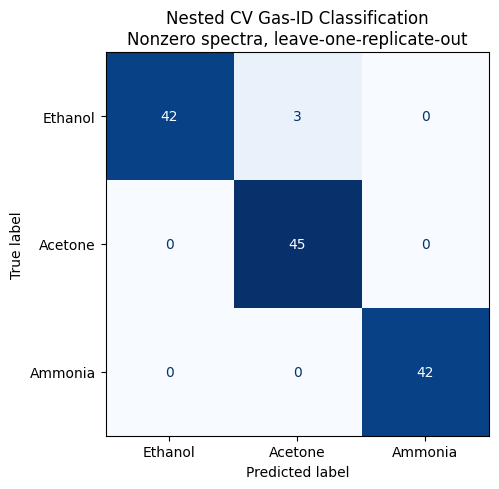


Errors only:


,Original_Gas_Label,Concentration,Replicate_ID,Filename,Nested_Rep_OOF_Predicted_Label
30,Ethanol,5.0,1,ethanol_5ppm_1.txt,Acetone
14,Ethanol,2.0,3,ethanol_2ppm_3.txt,Acetone
20,Ethanol,3.0,3,ethanol_3ppm_3.txt,Acetone



Classification protocol comparison:


,Protocol,Dataset,Selection,Outer_Group,Accuracy,Balanced_Accuracy,Macro_F1,Weighted_F1
0,Old-style baseline: includes 0 ppm as gas labe...,All spectra including blanks,Fixed,Concentration,0.949275,0.951389,0.951341,0.949226
1,"Corrected fixed baseline: nonzero gas ID, conc...",Nonzero spectra only,Fixed,Concentration,0.924242,0.925926,0.925779,0.924092
2,"Nested selected: nonzero gas ID, concentration...",Nonzero spectra only,Nested CV,Concentration,0.916667,0.918519,0.918428,0.916574
3,Fixed acquisition-surrogate holdout: nonzero g...,Nonzero spectra only,Fixed,Replicate_ID,0.977273,0.977778,0.977753,0.977247
4,Nested acquisition-surrogate holdout: nonzero ...,Nonzero spectra only,Nested CV,Replicate_ID,0.977273,0.977778,0.977753,0.977247


In [14]:
# ============================================================
# CELL 13: Nested CV classification by replicate/acquisition surrogate
# Nonzero gas-ID task only
# Outer LOGO = held-out Replicate_ID
# Inner LOGO = held-out Concentration within outer training
#
# Mirrors Cell 12's nested structure exactly, but swaps which column is
# the outer holdout group (Replicate_ID instead of Concentration) and
# which is the inner one (Concentration instead of Replicate_ID).
# Functions defined in Cell 12 (fit_predict_candidate,
# score_candidate_inner_logo) are reused unchanged. This produces the
# paper's "Nested acquisition-surrogate holdout" row (Table 9).
# ============================================================

start_time = time.time()

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------
nonzero_mask = df_cls["Concentration"].values > 0

X_raw_nonzero = X_raw[nonzero_mask]
df_nested_rep = df_cls.loc[nonzero_mask].copy().reset_index(drop=True)

y_rep_nested = df_nested_rep["Original_Gas_Label"].values
outer_groups_rep = df_nested_rep["Replicate_ID"].values
inner_groups_conc = df_nested_rep["Concentration"].values

outer_logo_rep = LeaveOneGroupOut()

nested_rep_oof_pred = np.empty(len(df_nested_rep), dtype=object)

outer_rep_rows = []
inner_rep_selection_rows = []

print("=" * 80)
print("NESTED CV CLASSIFICATION STARTED — REPLICATE HOLDOUT")
print("=" * 80)
print(f"N spectra: {len(df_nested_rep)}")
print(f"Classes: {sorted(np.unique(y_rep_nested))}")
print(f"Outer replicate groups: {sorted(np.unique(outer_groups_rep))}")
print(f"Inner selection grouping: Concentration")
print(f"N candidate pipelines: {len(preprocess_candidates)}")

# ------------------------------------------------------------
# Outer leave-one-replicate-out loop
# ------------------------------------------------------------

for outer_fold_id, (outer_train_idx, outer_test_idx) in enumerate(
    outer_logo_rep.split(X_raw_nonzero, y_rep_nested, groups=outer_groups_rep),
    start=1
):
    heldout_rep = outer_groups_rep[outer_test_idx][0]

    X_outer_train = X_raw_nonzero[outer_train_idx]
    X_outer_test = X_raw_nonzero[outer_test_idx]

    y_outer_train = y_rep_nested[outer_train_idx]
    y_outer_test = y_rep_nested[outer_test_idx]

    # Inner groups are concentrations inside the outer-training data
    groups_outer_train_inner = inner_groups_conc[outer_train_idx]

    print(f"\nOuter fold {outer_fold_id}: held-out Replicate_ID = {heldout_rep}")

    candidate_score_rows = []

    for candidate in preprocess_candidates:
        inner_scores = score_candidate_inner_logo(
            candidate=candidate,
            X_raw_train_outer=X_outer_train,
            y_train_outer=y_outer_train,
            groups_train_outer=groups_outer_train_inner,
            wavelengths=wl_reference
        )

        row = candidate.copy()
        row.update(inner_scores)
        row["Outer_Fold"] = outer_fold_id
        row["Heldout_Replicate_ID"] = heldout_rep

        candidate_score_rows.append(row)

    candidate_score_df = pd.DataFrame(candidate_score_rows)
    candidate_score_df["Candidate_Order"] = np.arange(len(candidate_score_df))

    candidate_score_df = candidate_score_df.sort_values(
        by=[
            "Mean_Inner_Balanced_Accuracy",
            "Pooled_Inner_Balanced_Accuracy",
            "Candidate_Order"
        ],
        ascending=[False, False, True]
    ).reset_index(drop=True)

    best_candidate = candidate_score_df.iloc[0].to_dict()

    inner_rep_selection_rows.extend(candidate_score_df.to_dict("records"))

    print(
        f"  Selected: {best_candidate['Candidate_ID']} | "
        f"Inner mean bal acc = {best_candidate['Mean_Inner_Balanced_Accuracy']:.4f}"
    )

    outer_pred = fit_predict_candidate(
        candidate=best_candidate,
        X_raw_train=X_outer_train,
        y_train=y_outer_train,
        X_raw_test=X_outer_test,
        wavelengths=wl_reference
    )

    nested_rep_oof_pred[outer_test_idx] = outer_pred

    outer_acc = accuracy_score(y_outer_test, outer_pred)
    outer_bal_acc = balanced_accuracy_score(y_outer_test, outer_pred)

    outer_rep_rows.append({
        "Outer_Fold": outer_fold_id,
        "Heldout_Replicate_ID": heldout_rep,
        "N_Test": len(outer_test_idx),
        "Classes_In_Test": ", ".join(sorted(np.unique(y_outer_test))),
        "Selected_Candidate_ID": best_candidate["Candidate_ID"],
        "Selected_WL_Min": best_candidate["WL_Min"],
        "Selected_WL_Max": best_candidate["WL_Max"],
        "Selected_Preprocess": best_candidate["Preprocess"],
        "Selected_Kernel": best_candidate["Kernel"],
        "Selected_C": best_candidate["C"],
        "Selected_Gamma": best_candidate["Gamma"],
        "Best_Inner_Mean_Balanced_Accuracy": best_candidate["Mean_Inner_Balanced_Accuracy"],
        "Outer_Accuracy": outer_acc,
        "Outer_Balanced_Accuracy": outer_bal_acc
    })

elapsed = time.time() - start_time

nested_rep_outer_df = pd.DataFrame(outer_rep_rows)
nested_rep_inner_selection_df = pd.DataFrame(inner_rep_selection_rows)

nested_rep_pred_df = df_nested_rep.copy()
nested_rep_pred_df["Nested_Rep_OOF_Predicted_Label"] = nested_rep_oof_pred
nested_rep_pred_df["Correct"] = (
    nested_rep_pred_df["Original_Gas_Label"] ==
    nested_rep_pred_df["Nested_Rep_OOF_Predicted_Label"]
)

nested_rep_acc = accuracy_score(y_rep_nested, nested_rep_oof_pred)
nested_rep_bal_acc = balanced_accuracy_score(y_rep_nested, nested_rep_oof_pred)
nested_rep_macro_f1 = f1_score(y_rep_nested, nested_rep_oof_pred, average="macro")
nested_rep_weighted_f1 = f1_score(y_rep_nested, nested_rep_oof_pred, average="weighted")

print("\n" + "=" * 80)
print("NESTED CV CLASSIFICATION RESULTS — REPLICATE HOLDOUT")
print("=" * 80)
print(f"Elapsed time:        {elapsed / 60:.2f} minutes")
print(f"Accuracy:            {nested_rep_acc:.4f} ({nested_rep_acc * 100:.2f}%)")
print(f"Balanced accuracy:   {nested_rep_bal_acc:.4f} ({nested_rep_bal_acc * 100:.2f}%)")
print(f"Macro F1:            {nested_rep_macro_f1:.4f}")
print(f"Weighted F1:         {nested_rep_weighted_f1:.4f}")

print("\nClassification report:")
print(classification_report(y_rep_nested, nested_rep_oof_pred, labels=labels_order_gases))

print("\nOuter replicate fold results:")
display(nested_rep_outer_df)

print("\nSelected candidate counts:")
display(
    nested_rep_outer_df["Selected_Candidate_ID"]
    .value_counts()
    .rename_axis("Candidate_ID")
    .reset_index(name="Selected_Count")
)

print("\nAccuracy by gas and held-out replicate:")
display(
    nested_rep_pred_df
    .groupby(["Original_Gas_Label", "Replicate_ID"])
    .agg(
        N=("Correct", "size"),
        Accuracy=("Correct", "mean")
    )
    .reset_index()
)

cm_nested_rep = confusion_matrix(
    y_rep_nested,
    nested_rep_oof_pred,
    labels=labels_order_gases
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nested_rep,
    display_labels=labels_order_gases
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
plt.title("Nested CV Gas-ID Classification\nNonzero spectra, leave-one-replicate-out")
plt.tight_layout()
plt.show()

print("\nErrors only:")
display(
    nested_rep_pred_df.loc[
        ~nested_rep_pred_df["Correct"],
        [
            "Original_Gas_Label",
            "Concentration",
            "Replicate_ID",
            "Filename",
            "Nested_Rep_OOF_Predicted_Label"
        ]
    ].sort_values(["Replicate_ID", "Original_Gas_Label", "Concentration"])
)

# ------------------------------------------------------------
# Updated protocol comparison table
# ------------------------------------------------------------

classification_protocol_comparison = pd.DataFrame([
    {
        "Protocol": "Old-style baseline: includes 0 ppm as gas labels, concentration LOGO",
        "Dataset": "All spectra including blanks",
        "Selection": "Fixed",
        "Outer_Group": "Concentration",
        "Accuracy": baseline_acc,
        "Balanced_Accuracy": baseline_bal_acc,
        "Macro_F1": baseline_macro_f1,
        "Weighted_F1": baseline_weighted_f1
    },
    {
        "Protocol": "Corrected fixed baseline: nonzero gas ID, concentration LOGO",
        "Dataset": "Nonzero spectra only",
        "Selection": "Fixed",
        "Outer_Group": "Concentration",
        "Accuracy": nonzero_metrics["accuracy"],
        "Balanced_Accuracy": nonzero_metrics["balanced_accuracy"],
        "Macro_F1": nonzero_metrics["macro_f1"],
        "Weighted_F1": nonzero_metrics["weighted_f1"]
    },
    {
        "Protocol": "Nested selected: nonzero gas ID, concentration LOGO",
        "Dataset": "Nonzero spectra only",
        "Selection": "Nested CV",
        "Outer_Group": "Concentration",
        "Accuracy": nested_acc,
        "Balanced_Accuracy": nested_bal_acc,
        "Macro_F1": nested_macro_f1,
        "Weighted_F1": nested_weighted_f1
    },
    {
        "Protocol": "Fixed acquisition-surrogate holdout: nonzero gas ID, replicate LOGO",
        "Dataset": "Nonzero spectra only",
        "Selection": "Fixed",
        "Outer_Group": "Replicate_ID",
        "Accuracy": replicate_metrics["accuracy"],
        "Balanced_Accuracy": replicate_metrics["balanced_accuracy"],
        "Macro_F1": replicate_metrics["macro_f1"],
        "Weighted_F1": replicate_metrics["weighted_f1"]
    },
    {
        "Protocol": "Nested acquisition-surrogate holdout: nonzero gas ID, replicate LOGO",
        "Dataset": "Nonzero spectra only",
        "Selection": "Nested CV",
        "Outer_Group": "Replicate_ID",
        "Accuracy": nested_rep_acc,
        "Balanced_Accuracy": nested_rep_bal_acc,
        "Macro_F1": nested_rep_macro_f1,
        "Weighted_F1": nested_rep_weighted_f1
    }
])

print("\nClassification protocol comparison:")
display(classification_protocol_comparison)

In [15]:
# ============================================================
# CELL 14: Clean final summary tables for classification section
#
# Reformats the raw result dataframes produced by Cells 5/6/10/12/13
# into rounded, percentage-scaled tables ready to drop into the paper
# (Table 9 and related error breakdowns), and writes them to CSV.
# ============================================================

def round_metric_table(df, metric_cols=None, digits=4):
    """Return a copy of df with the given metric columns rounded."""
    df_out = df.copy()
    if metric_cols is None:
        metric_cols = [
            "Accuracy",
            "Balanced_Accuracy",
            "Macro_F1",
            "Weighted_F1"
        ]
    for col in metric_cols:
        if col in df_out.columns:
            df_out[col] = df_out[col].astype(float).round(digits)
    return df_out


print("=" * 80)
print("FINAL CLASSIFICATION PROTOCOL COMPARISON")
print("=" * 80)

protocol_summary_clean = classification_protocol_comparison.copy()

protocol_summary_clean["Accuracy_%"] = protocol_summary_clean["Accuracy"] * 100
protocol_summary_clean["Balanced_Accuracy_%"] = protocol_summary_clean["Balanced_Accuracy"] * 100
protocol_summary_clean["Macro_F1"] = protocol_summary_clean["Macro_F1"]
protocol_summary_clean["Weighted_F1"] = protocol_summary_clean["Weighted_F1"]

protocol_summary_clean = protocol_summary_clean[[
    "Protocol",
    "Dataset",
    "Selection",
    "Outer_Group",
    "Accuracy_%",
    "Balanced_Accuracy_%",
    "Macro_F1",
    "Weighted_F1"
]]

protocol_summary_clean[[
    "Accuracy_%",
    "Balanced_Accuracy_%",
    "Macro_F1",
    "Weighted_F1"
]] = protocol_summary_clean[[
    "Accuracy_%",
    "Balanced_Accuracy_%",
    "Macro_F1",
    "Weighted_F1"
]].round(2)

display(protocol_summary_clean)


print("\n" + "=" * 80)
print("NESTED CONCENTRATION-HOLDOUT: SELECTED CANDIDATES")
print("=" * 80)

nested_conc_candidate_counts = (
    nested_outer_df["Selected_Candidate_ID"]
    .value_counts()
    .rename_axis("Candidate_ID")
    .reset_index(name="Selected_Count")
)

display(nested_conc_candidate_counts)


print("\n" + "=" * 80)
print("NESTED REPLICATE-HOLDOUT: SELECTED CANDIDATES")
print("=" * 80)

nested_rep_candidate_counts = (
    nested_rep_outer_df["Selected_Candidate_ID"]
    .value_counts()
    .rename_axis("Candidate_ID")
    .reset_index(name="Selected_Count")
)

display(nested_rep_candidate_counts)


print("\n" + "=" * 80)
print("NESTED CONCENTRATION-HOLDOUT: OUTER FOLD SUMMARY")
print("=" * 80)

nested_conc_outer_clean = nested_outer_df[[
    "Heldout_Concentration",
    "N_Test",
    "Selected_Candidate_ID",
    "Best_Inner_Mean_Balanced_Accuracy",
    "Outer_Accuracy",
    "Outer_Balanced_Accuracy"
]].copy()

nested_conc_outer_clean[[
    "Best_Inner_Mean_Balanced_Accuracy",
    "Outer_Accuracy",
    "Outer_Balanced_Accuracy"
]] = nested_conc_outer_clean[[
    "Best_Inner_Mean_Balanced_Accuracy",
    "Outer_Accuracy",
    "Outer_Balanced_Accuracy"
]].round(4)

display(nested_conc_outer_clean)


print("\n" + "=" * 80)
print("NESTED REPLICATE-HOLDOUT: OUTER FOLD SUMMARY")
print("=" * 80)

nested_rep_outer_clean = nested_rep_outer_df[[
    "Heldout_Replicate_ID",
    "N_Test",
    "Selected_Candidate_ID",
    "Best_Inner_Mean_Balanced_Accuracy",
    "Outer_Accuracy",
    "Outer_Balanced_Accuracy"
]].copy()

nested_rep_outer_clean[[
    "Best_Inner_Mean_Balanced_Accuracy",
    "Outer_Accuracy",
    "Outer_Balanced_Accuracy"
]] = nested_rep_outer_clean[[
    "Best_Inner_Mean_Balanced_Accuracy",
    "Outer_Accuracy",
    "Outer_Balanced_Accuracy"
]].round(4)

display(nested_rep_outer_clean)


print("\n" + "=" * 80)
print("ERROR COUNTS BY PROTOCOL")
print("=" * 80)

error_summary = pd.DataFrame([
    {
        "Protocol": "Corrected fixed concentration LOGO",
        "Errors": int((~nonzero_pred_df["Correct"]).sum()),
        "Total": len(nonzero_pred_df)
    },
    {
        "Protocol": "Nested concentration LOGO",
        "Errors": int((~nested_pred_df["Correct"]).sum()),
        "Total": len(nested_pred_df)
    },
    {
        "Protocol": "Fixed replicate LOGO",
        "Errors": int((~replicate_pred_df["Correct"]).sum()),
        "Total": len(replicate_pred_df)
    },
    {
        "Protocol": "Nested replicate LOGO",
        "Errors": int((~nested_rep_pred_df["Correct"]).sum()),
        "Total": len(nested_rep_pred_df)
    }
])

error_summary["Error_Rate_%"] = 100 * error_summary["Errors"] / error_summary["Total"]
error_summary["Error_Rate_%"] = error_summary["Error_Rate_%"].round(2)

display(error_summary)


print("\n" + "=" * 80)
print("NESTED REPLICATE-HOLDOUT ERRORS ONLY")
print("=" * 80)

nested_rep_errors_clean = nested_rep_pred_df.loc[
    ~nested_rep_pred_df["Correct"],
    [
        "Original_Gas_Label",
        "Concentration",
        "Replicate_ID",
        "Filename",
        "Nested_Rep_OOF_Predicted_Label"
    ]
].sort_values(["Replicate_ID", "Original_Gas_Label", "Concentration"])

display(nested_rep_errors_clean)


# ------------------------------------------------------------
# Save tables for paper/report use
# ------------------------------------------------------------

protocol_summary_clean.to_csv("classification_protocol_summary.csv", index=False)
nested_conc_outer_clean.to_csv("nested_concentration_outer_folds.csv", index=False)
nested_rep_outer_clean.to_csv("nested_replicate_outer_folds.csv", index=False)
error_summary.to_csv("classification_error_summary.csv", index=False)
nested_rep_errors_clean.to_csv("nested_replicate_errors.csv", index=False)

print("\nSaved CSV files:")
print("- classification_protocol_summary.csv")
print("- nested_concentration_outer_folds.csv")
print("- nested_replicate_outer_folds.csv")
print("- classification_error_summary.csv")
print("- nested_replicate_errors.csv")

FINAL CLASSIFICATION PROTOCOL COMPARISON


,Protocol,Dataset,Selection,Outer_Group,Accuracy_%,Balanced_Accuracy_%,Macro_F1,Weighted_F1
0,Old-style baseline: includes 0 ppm as gas labe...,All spectra including blanks,Fixed,Concentration,94.93,95.14,0.95,0.95
1,"Corrected fixed baseline: nonzero gas ID, conc...",Nonzero spectra only,Fixed,Concentration,92.42,92.59,0.93,0.92
2,"Nested selected: nonzero gas ID, concentration...",Nonzero spectra only,Nested CV,Concentration,91.67,91.85,0.92,0.92
3,Fixed acquisition-surrogate holdout: nonzero g...,Nonzero spectra only,Fixed,Replicate_ID,97.73,97.78,0.98,0.98
4,Nested acquisition-surrogate holdout: nonzero ...,Nonzero spectra only,Nested CV,Replicate_ID,97.73,97.78,0.98,0.98



NESTED CONCENTRATION-HOLDOUT: SELECTED CANDIDATES


,Candidate_ID,Selected_Count
0,600_900_snv_rbf_C10,17
1,500_900_snv_rbf_C10,5
2,500_900_snv_savgol_rbf_C10,1



NESTED REPLICATE-HOLDOUT: SELECTED CANDIDATES


...


ERROR COUNTS BY PROTOCOL


,Protocol,Errors,Total,Error_Rate_%
0,Corrected fixed concentration LOGO,10,132,7.58
1,Nested concentration LOGO,11,132,8.33
2,Fixed replicate LOGO,3,132,2.27
3,Nested replicate LOGO,3,132,2.27



NESTED REPLICATE-HOLDOUT ERRORS ONLY


,Original_Gas_Label,Concentration,Replicate_ID,Filename,Nested_Rep_OOF_Predicted_Label
30,Ethanol,5.0,1,ethanol_5ppm_1.txt,Acetone
14,Ethanol,2.0,3,ethanol_2ppm_3.txt,Acetone
20,Ethanol,3.0,3,ethanol_3ppm_3.txt,Acetone



Saved CSV files:
- classification_protocol_summary.csv
- nested_concentration_outer_folds.csv
- nested_replicate_outer_folds.csv
- classification_error_summary.csv
- nested_replicate_errors.csv


Evaluating 400-900 nm | features = 1961
Evaluating 450-900 nm | features = 1770
Evaluating 500-900 nm | features = 1579
Evaluating 550-900 nm | features = 1386
Evaluating 600-900 nm | features = 1192
Evaluating 650-900 nm | features = 997
Evaluating 500-850 nm | features = 1377
Evaluating 500-950 nm | features = 1782
Evaluating 500-1000 nm | features = 1988
Evaluating 400-1000 nm | features = 2370
Evaluating 600-1000 nm | features = 1601

WAVELENGTH WINDOW ABLATION RESULTS


,Window,N_Features,Concentration_LOGO_Balanced_Accuracy,Replicate_LOGO_Balanced_Accuracy,Mean_Balanced_Accuracy,Minimum_Balanced_Accuracy,Concentration_LOGO_Accuracy,Replicate_LOGO_Accuracy
0,500-850,1377,96.30,97.04,96.67,96.30,96.21,96.97
1,600-900,1192,95.56,96.30,95.93,95.56,95.45,96.21
2,450-900,1770,94.81,96.30,95.56,94.81,94.70,96.21
3,550-900,1386,94.07,95.56,94.81,94.07,93.94,95.45
4,500-950,1782,94.81,94.07,94.44,94.07,94.70,93.94
5,650-900,997,93.33,96.30,94.81,93.33,93.18,96.21
6,500-900,1579,92.59,97.78,95.19,92.59,92.42,97.73
7,500-1000,1988,92.59,91.85,92.22,91.85,92.42,91.67
8,400-900,1961,91.85,89.63,90.74,89.63,91.67,89.39
9,600-1000,1601,88.89,90.37,89.63,88.89,88.64,90.15



500–900 nm RANK CHECK


,Rank_By_Robust_Score,Window,N_Features,Concentration_LOGO_Balanced_Accuracy,Replicate_LOGO_Balanced_Accuracy,Mean_Balanced_Accuracy,Minimum_Balanced_Accuracy
6,7,500-900,1579,0.925926,0.977778,0.951852,0.925926


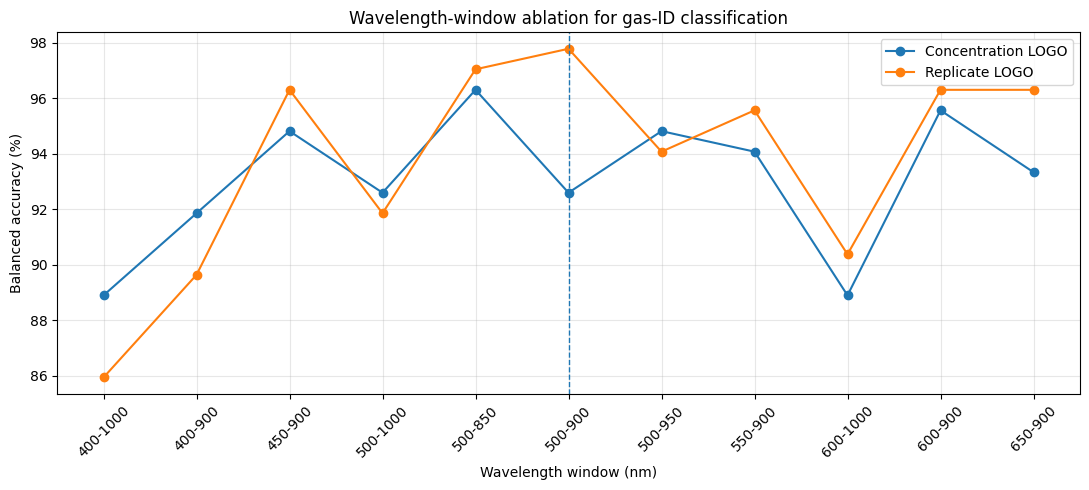


Saved:
- wavelength_window_ablation_classification.csv


In [16]:
# ============================================================
# CELL 15: Wavelength-window ablation
# Purpose: empirically justify whether 500–900 nm is defensible
#
# Sweeps a fixed model (SNV + RBF SVC, C=10) across alternative
# wavelength windows, evaluating each one under both the concentration
# holdout and the replicate/acquisition-surrogate holdout. This is
# explicitly a post hoc sensitivity analysis (paper Section G, Figure
# 8) run after the primary 500–900 nm window was already fixed; it is
# not used to choose the final model.
# ============================================================

def evaluate_fixed_candidate_logo_raw(
    X_raw_eval,
    df_eval,
    y_col,
    group_col,
    candidate,
    labels_order,
    wavelengths
):
    """
    Evaluate one fixed candidate using LOGO.
    Starts from raw spectra and applies candidate preprocessing inside each fold.
    """

    df_eval = df_eval.reset_index(drop=True).copy()
    y = df_eval[y_col].values
    groups = df_eval[group_col].values

    logo = LeaveOneGroupOut()

    oof_pred = np.empty(len(df_eval), dtype=object)
    fold_rows = []

    for fold_id, (train_idx, test_idx) in enumerate(
        logo.split(X_raw_eval, y, groups=groups),
        start=1
    ):
        X_train = X_raw_eval[train_idx]
        X_test = X_raw_eval[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        heldout_group = groups[test_idx][0]

        y_pred = fit_predict_candidate(
            candidate=candidate,
            X_raw_train=X_train,
            y_train=y_train,
            X_raw_test=X_test,
            wavelengths=wavelengths
        )

        oof_pred[test_idx] = y_pred

        fold_rows.append({
            "Fold": fold_id,
            f"Heldout_{group_col}": heldout_group,
            "N_Test": len(test_idx),
            "Fold_Accuracy": accuracy_score(y_test, y_pred),
            "Fold_Balanced_Accuracy": balanced_accuracy_score(y_test, y_pred)
        })

    acc = accuracy_score(y, oof_pred)
    bal_acc = balanced_accuracy_score(y, oof_pred)
    macro_f1 = f1_score(y, oof_pred, average="macro")
    weighted_f1 = f1_score(y, oof_pred, average="weighted")

    pred_df = df_eval.copy()
    pred_df["Predicted"] = oof_pred
    pred_df["Correct"] = pred_df[y_col] == pred_df["Predicted"]

    return {
        "Accuracy": acc,
        "Balanced_Accuracy": bal_acc,
        "Macro_F1": macro_f1,
        "Weighted_F1": weighted_f1,
        "Fold_DF": pd.DataFrame(fold_rows),
        "Pred_DF": pred_df
    }


# ------------------------------------------------------------
# Nonzero gas-ID dataset
# ------------------------------------------------------------

nonzero_mask = df_cls["Concentration"].values > 0

X_raw_nonzero = X_raw[nonzero_mask]
df_window = df_cls.loc[nonzero_mask].copy().reset_index(drop=True)

labels_order_gases = ["Ethanol", "Acetone", "Ammonia"]

# ------------------------------------------------------------
# Candidate wavelength windows
# Keep model fixed: SNV + RBF SVC C=10
# This isolates the effect of wavelength window.
# ------------------------------------------------------------

window_candidates = [
    (400, 900),
    (450, 900),
    (500, 900),
    (550, 900),
    (600, 900),
    (650, 900),
    (500, 850),
    (500, 950),
    (500, 1000),
    (400, 1000),
    (600, 1000)
]

window_results = []

for wl_min, wl_max in window_candidates:
    # Skip impossible windows outside available spectral range
    if wl_min < wl_reference.min() or wl_max > wl_reference.max():
        print(f"Skipping {wl_min}-{wl_max} nm because it is outside available wavelength range.")
        continue

    candidate = {
        "Candidate_ID": f"{wl_min}_{wl_max}_snv_rbf_C10",
        "WL_Min": wl_min,
        "WL_Max": wl_max,
        "Preprocess": "snv",
        "Kernel": "rbf",
        "C": 10,
        "Gamma": "scale"
    }

    wl_mask = (wl_reference >= wl_min) & (wl_reference <= wl_max)
    n_features = int(wl_mask.sum())

    print(f"Evaluating {wl_min}-{wl_max} nm | features = {n_features}")

    # Concentration holdout
    conc_result = evaluate_fixed_candidate_logo_raw(
        X_raw_eval=X_raw_nonzero,
        df_eval=df_window,
        y_col="Original_Gas_Label",
        group_col="Concentration",
        candidate=candidate,
        labels_order=labels_order_gases,
        wavelengths=wl_reference
    )

    # Replicate / acquisition-surrogate holdout
    rep_result = evaluate_fixed_candidate_logo_raw(
        X_raw_eval=X_raw_nonzero,
        df_eval=df_window,
        y_col="Original_Gas_Label",
        group_col="Replicate_ID",
        candidate=candidate,
        labels_order=labels_order_gases,
        wavelengths=wl_reference
    )

    window_results.append({
        "Window": f"{wl_min}-{wl_max}",
        "WL_Min": wl_min,
        "WL_Max": wl_max,
        "N_Features": n_features,

        "Concentration_LOGO_Accuracy": conc_result["Accuracy"],
        "Concentration_LOGO_Balanced_Accuracy": conc_result["Balanced_Accuracy"],
        "Concentration_LOGO_Macro_F1": conc_result["Macro_F1"],

        "Replicate_LOGO_Accuracy": rep_result["Accuracy"],
        "Replicate_LOGO_Balanced_Accuracy": rep_result["Balanced_Accuracy"],
        "Replicate_LOGO_Macro_F1": rep_result["Macro_F1"],

        # Conservative combined score:
        # rewards windows that perform well under both tests
        "Mean_Balanced_Accuracy": np.mean([
            conc_result["Balanced_Accuracy"],
            rep_result["Balanced_Accuracy"]
        ]),
        "Minimum_Balanced_Accuracy": min(
            conc_result["Balanced_Accuracy"],
            rep_result["Balanced_Accuracy"]
        )
    })

window_ablation_df = pd.DataFrame(window_results)

# ------------------------------------------------------------
# Clean display table
# ------------------------------------------------------------

display_cols = [
    "Window",
    "N_Features",
    "Concentration_LOGO_Balanced_Accuracy",
    "Replicate_LOGO_Balanced_Accuracy",
    "Mean_Balanced_Accuracy",
    "Minimum_Balanced_Accuracy",
    "Concentration_LOGO_Accuracy",
    "Replicate_LOGO_Accuracy"
]

window_ablation_clean = window_ablation_df[display_cols].copy()

metric_cols = [
    "Concentration_LOGO_Balanced_Accuracy",
    "Replicate_LOGO_Balanced_Accuracy",
    "Mean_Balanced_Accuracy",
    "Minimum_Balanced_Accuracy",
    "Concentration_LOGO_Accuracy",
    "Replicate_LOGO_Accuracy"
]

for col in metric_cols:
    window_ablation_clean[col] = (100 * window_ablation_clean[col]).round(2)

print("\n" + "=" * 80)
print("WAVELENGTH WINDOW ABLATION RESULTS")
print("=" * 80)

display(
    window_ablation_clean
    .sort_values(
        by=["Minimum_Balanced_Accuracy", "Mean_Balanced_Accuracy"],
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Rank of 500–900 nm
# ------------------------------------------------------------

ranked = (
    window_ablation_df
    .sort_values(
        by=["Minimum_Balanced_Accuracy", "Mean_Balanced_Accuracy"],
        ascending=False
    )
    .reset_index(drop=True)
)

ranked["Rank_By_Robust_Score"] = np.arange(1, len(ranked) + 1)

target_row = ranked[ranked["Window"] == "500-900"]

print("\n" + "=" * 80)
print("500–900 nm RANK CHECK")
print("=" * 80)

if len(target_row) == 1:
    display(target_row[[
        "Rank_By_Robust_Score",
        "Window",
        "N_Features",
        "Concentration_LOGO_Balanced_Accuracy",
        "Replicate_LOGO_Balanced_Accuracy",
        "Mean_Balanced_Accuracy",
        "Minimum_Balanced_Accuracy"
    ]])
else:
    print("500–900 nm window was not evaluated.")

# ------------------------------------------------------------
# Plot balanced accuracy by window
# ------------------------------------------------------------

plot_df = window_ablation_clean.sort_values("Window")

plt.figure(figsize=(11, 5))
plt.plot(
    plot_df["Window"],
    plot_df["Concentration_LOGO_Balanced_Accuracy"],
    marker="o",
    label="Concentration LOGO"
)
plt.plot(
    plot_df["Window"],
    plot_df["Replicate_LOGO_Balanced_Accuracy"],
    marker="o",
    label="Replicate LOGO"
)
plt.axvline(
    x=list(plot_df["Window"]).index("500-900") if "500-900" in list(plot_df["Window"]) else 0,
    linestyle="--",
    linewidth=1
)
plt.xticks(rotation=45)
plt.ylabel("Balanced accuracy (%)")
plt.xlabel("Wavelength window (nm)")
plt.title("Wavelength-window ablation for gas-ID classification")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Save table
# ------------------------------------------------------------

window_ablation_clean.to_csv("wavelength_window_ablation_classification.csv", index=False)

print("\nSaved:")
print("- wavelength_window_ablation_classification.csv")

F5 CLASSIFICATION PROTOCOL TABLE


,Protocol,Balanced_Accuracy_Percent,Interpretation
0,Historical\n0 ppm included,95.14,Historical/confounded baseline; 0 ppm treated ...
1,Corrected fixed\nnonzero LOCO,92.59,Corrected gas-ID task; blanks removed
2,Nested\nnonzero LOCO,91.85,Preprocessing/model selected inside inner CV
3,Nested acquisition-\nsurrogate LORO,97.78,Acquisition-surrogate robustness check


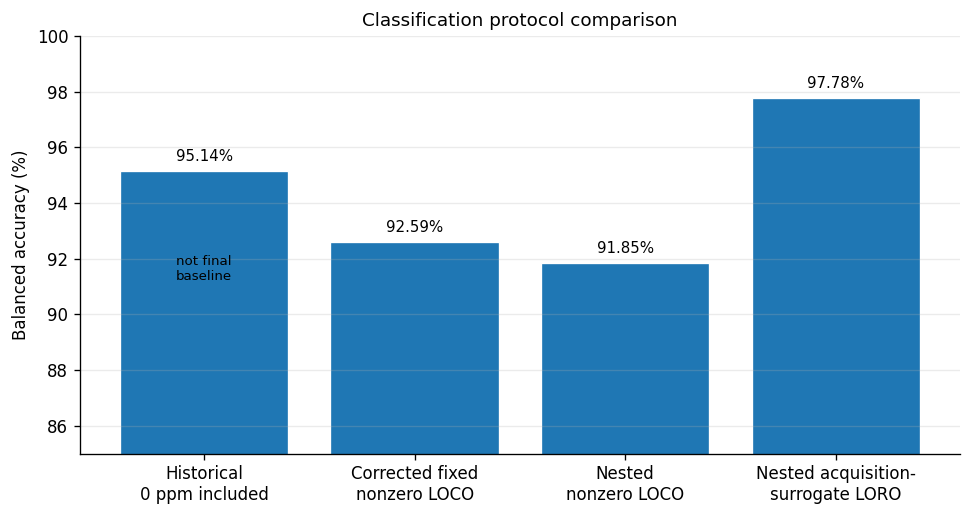

Saved: figures\F5_classification_protocol_comparison.png
Saved: figures\F5_classification_protocol_comparison.pdf
Saved: figures\F5_classification_protocol_comparison.csv


In [17]:
# ============================================================
# F5: Classification protocol comparison bar chart
# Paste this in the CLASSIFICATION notebook near the end.
#
# Purpose:
# Compare balanced accuracy across classification protocols:
# 1. Historical / old blank-included baseline
# 2. Corrected nonzero-only concentration LOGO
# 3. Nested concentration LOGO
# 4. Nested replicate/acquisition-surrogate LOGO
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------
OUTDIR = "figures"
os.makedirs(OUTDIR, exist_ok=True)

# ------------------------------------------------------------
# Publication-style plotting settings
# ------------------------------------------------------------
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "figure.autolayout": True,
})

# ------------------------------------------------------------
# Classification protocol results
# These are your current final values.
# Keep 500–900 nm as the primary fixed window.
# 500–850 nm remains exploratory/post-hoc only.
#
# NOTE (flagged, not changed): these four numbers are typed in by hand
# rather than read from baseline_bal_acc / nonzero_metrics /
# nested_bal_acc / nested_rep_bal_acc computed earlier in this
# notebook. If the upstream cells are ever re-run on different data,
# this figure will not automatically update and could silently
# disagree with the live results above it.
# ------------------------------------------------------------

f5_protocol_table = pd.DataFrame({
    "Protocol": [
        "Historical\n0 ppm included",
        "Corrected fixed\nnonzero LOCO",
        "Nested\nnonzero LOCO",
        "Nested acquisition-\nsurrogate LORO"
    ],
    "Balanced_Accuracy_Percent": [
        95.14,  # old-style baseline, includes 0 ppm as gas labels
        92.59,  # corrected fixed baseline, nonzero only, concentration LOGO
        91.85,  # nested selected, nonzero only, concentration LOGO
        97.78   # nested selected, nonzero only, replicate holdout
    ],
    "Interpretation": [
        "Historical/confounded baseline; 0 ppm treated as gas labels",
        "Corrected gas-ID task; blanks removed",
        "Preprocessing/model selected inside inner CV",
        "Acquisition-surrogate robustness check"
    ]
})

print("=" * 80)
print("F5 CLASSIFICATION PROTOCOL TABLE")
print("=" * 80)
display(f5_protocol_table)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.2, 4.4))

x = np.arange(len(f5_protocol_table))
values = f5_protocol_table["Balanced_Accuracy_Percent"].values

bars = ax.bar(
    x,
    values,
    edgecolor="white",
    linewidth=0.8
)

ax.set_xticks(x)
ax.set_xticklabels(
    f5_protocol_table["Protocol"],
    rotation=0,
    ha="center"
)

ax.set_ylabel("Balanced accuracy (%)")
ax.set_ylim(85, 100)
ax.set_title("Classification protocol comparison")

ax.grid(axis="y", alpha=0.25)

# Value labels
for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.25,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

# Mark the historical/confounded baseline visually with text
ax.text(
    x[0],
    values[0] - 3.0,
    "not final\nbaseline",
    ha="center",
    va="top",
    fontsize=8
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Save figure and table
# ------------------------------------------------------------
png_path = os.path.join(OUTDIR, "F5_classification_protocol_comparison.png")
pdf_path = os.path.join(OUTDIR, "F5_classification_protocol_comparison.pdf")
csv_path = os.path.join(OUTDIR, "F5_classification_protocol_comparison.csv")

fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
f5_protocol_table.to_csv(csv_path, index=False)

print(f"Saved: {png_path}")
print(f"Saved: {pdf_path}")
print(f"Saved: {csv_path}")

F6 CONFUSION MATRIX: FINAL NESTED NONZERO CLASSIFICATION


,Pred_Acetone,Pred_Ammonia,Pred_Ethanol
True_Acetone,41,0,4
True_Ammonia,0,42,0
True_Ethanol,7,0,38



Classification report:
              precision    recall  f1-score   support

     Acetone       0.85      0.91      0.88        45
     Ammonia       1.00      1.00      1.00        42
     Ethanol       0.90      0.84      0.87        45

    accuracy                           0.92       132
   macro avg       0.92      0.92      0.92       132
weighted avg       0.92      0.92      0.92       132



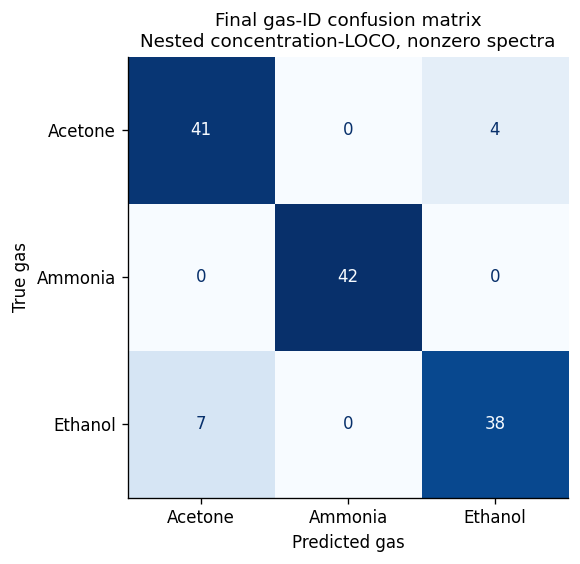

Saved: figures\F6_final_nested_confusion_matrix.png
Saved: figures\F6_final_nested_confusion_matrix.pdf
Saved: figures\F6_final_nested_confusion_matrix.csv

Errors only:


,Original_Gas_Label,Nested_OOF_Predicted_Label,Concentration,Replicate_ID,Filename
75,Acetone,Ethanol,5.0,1,acetone_5ppm_1.txt
80,Acetone,Ethanol,60.0,3,acetone_60ppm_3.txt
85,Acetone,Ethanol,80.0,2,acetone_80ppm_2.txt
88,Acetone,Ethanol,90.0,2,acetone_90ppm_2.txt
6,Ethanol,Acetone,1.0,1,ethanol_1ppm_1.txt
7,Ethanol,Acetone,1.0,2,ethanol_1ppm_2.txt
14,Ethanol,Acetone,2.0,3,ethanol_2ppm_3.txt
20,Ethanol,Acetone,3.0,3,ethanol_3ppm_3.txt
26,Ethanol,Acetone,4.0,3,ethanol_4ppm_3.txt
30,Ethanol,Acetone,5.0,1,ethanol_5ppm_1.txt


Saved: figures\F6_final_nested_classification_errors.csv


In [20]:
# ============================================================
# F6: Confusion matrix for final corrected classification model
# Paste this in the CLASSIFICATION notebook near the end.
#
# Uses:
# - nested_pred_df
# - Original_Gas_Label
# - Nested_OOF_Predicted_Label
#
# This should represent the final nonzero gas-ID nested concentration-LOGO result.
# Produces the paper's Figure 7 confusion matrix and Table 10
# classification report.
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------
OUTDIR = "figures"
os.makedirs(OUTDIR, exist_ok=True)

# ------------------------------------------------------------
# Publication-style plotting settings
# ------------------------------------------------------------
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "figure.autolayout": True,
})

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------
if "nested_pred_df" not in globals():
    raise ValueError(
        "nested_pred_df not found. Run the nested concentration-LOGO classification cell first."
    )

required_cols = {"Original_Gas_Label", "Nested_OOF_Predicted_Label", "Concentration"}

missing_cols = required_cols - set(nested_pred_df.columns)
if missing_cols:
    raise ValueError(f"nested_pred_df is missing columns: {missing_cols}")

# ------------------------------------------------------------
# Use final corrected nonzero nested concentration-LOGO predictions
# ------------------------------------------------------------
f6_df = nested_pred_df.copy()

# Safety: make sure this is nonzero-only
# FLAGGED, NOT FIXED: `.any` here is a bound-method reference, not a
# call (`.any()`). A method object is always truthy, so this outer
# `if` always evaluates to True regardless of the data. The actual
# safety check below it (`.sum() > 0`) is written correctly, so this
# has no effect on the result here -- but the outer line does not do
# what its comment/intent suggests. See chat for details.
if (f6_df["Concentration"] == 0).any:
    if (f6_df["Concentration"] == 0).sum() > 0:
        raise ValueError(
            "F6 should use nonzero-only gas-ID predictions, but 0 ppm rows are present."
        )

y_true = f6_df["Original_Gas_Label"].values
y_pred = f6_df["Nested_OOF_Predicted_Label"].values

labels_order = ["Acetone", "Ammonia", "Ethanol"]

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=labels_order
)

cm_df = pd.DataFrame(
    cm,
    index=[f"True_{x}" for x in labels_order],
    columns=[f"Pred_{x}" for x in labels_order]
)

print("=" * 80)
print("F6 CONFUSION MATRIX: FINAL NESTED NONZERO CLASSIFICATION")
print("=" * 80)
display(cm_df)

print("\nClassification report:")
print(classification_report(y_true, y_pred, labels=labels_order))

# ------------------------------------------------------------
# Plot confusion matrix
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5.3, 4.8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels_order
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

ax.set_title("Final gas-ID confusion matrix\nNested concentration-LOCO, nonzero spectra")
ax.set_xlabel("Predicted gas")
ax.set_ylabel("True gas")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Save figure and table
# ------------------------------------------------------------
png_path = os.path.join(OUTDIR, "F6_final_nested_confusion_matrix.png")
pdf_path = os.path.join(OUTDIR, "F6_final_nested_confusion_matrix.pdf")
csv_path = os.path.join(OUTDIR, "F6_final_nested_confusion_matrix.csv")

fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
cm_df.to_csv(csv_path)

print(f"Saved: {png_path}")
print(f"Saved: {pdf_path}")
print(f"Saved: {csv_path}")

# ------------------------------------------------------------
# Error table for interpretation
# ------------------------------------------------------------
f6_error_df = f6_df.loc[
    f6_df["Original_Gas_Label"] != f6_df["Nested_OOF_Predicted_Label"],
    [
        "Original_Gas_Label",
        "Nested_OOF_Predicted_Label",
        "Concentration",
        "Replicate_ID",
        "Filename"
    ]
].sort_values(["Original_Gas_Label", "Concentration", "Replicate_ID"])

print("\nErrors only:")
display(f6_error_df)

error_csv_path = os.path.join(OUTDIR, "F6_final_nested_classification_errors.csv")
f6_error_df.to_csv(error_csv_path, index=False)

print(f"Saved: {error_csv_path}")

F7 WAVELENGTH-WINDOW SENSITIVITY TABLE


,Window,N_Features,Conc_LOCO_Balanced_Accuracy,Repl_LORO_Balanced_Accuracy,Mean_Balanced_Accuracy,Minimum_Balanced_Accuracy
0,400-900,1961,91.85,89.63,90.740,89.63
1,450-900,1770,94.81,96.30,95.555,94.81
2,500-900,1579,92.59,97.78,95.185,92.59
3,550-900,1386,94.07,95.56,94.815,94.07
4,600-900,1192,95.56,96.30,95.930,95.56
5,650-900,997,93.33,96.30,94.815,93.33
6,500-850,1377,96.30,97.04,96.670,96.30
7,500-950,1782,94.81,94.07,94.440,94.07
8,500-1000,1988,92.59,91.85,92.220,91.85
9,400-1000,2370,88.89,85.93,87.410,85.93


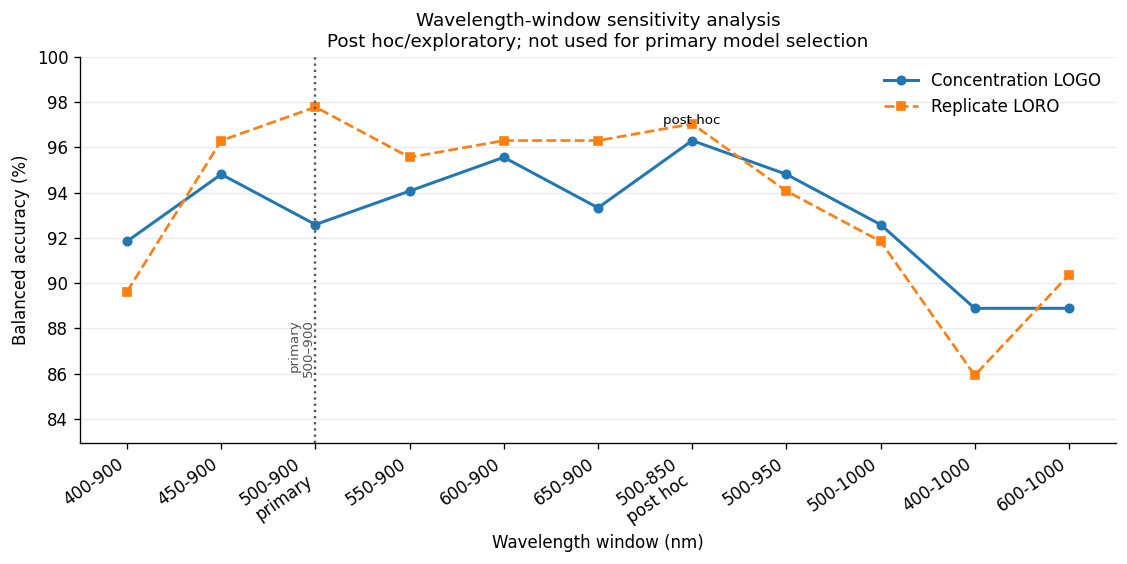

Saved: figures\F7_wavelength_window_sensitivity.png
Saved: figures\F7_wavelength_window_sensitivity.pdf
Saved: figures\F7_wavelength_window_sensitivity.csv

F7 INTERPRETATION
Best post hoc robust window by minimum balanced accuracy: 500-850 (minimum balanced accuracy = 96.30%)
Primary predefined window: 500–900 nm (concentration LOGO balanced accuracy = 92.59%, replicate LORO balanced accuracy = 97.78%)

Paper-safe interpretation: 500–850 nm is reported only as a post hoc sensitivity result. The primary classifier remains 500–900 nm to avoid full-dataset wavelength-window selection leakage.


In [21]:
# ============================================================
# F7: Wavelength-window sensitivity analysis
# Paste this in the CLASSIFICATION notebook near the end.
#
# Purpose:
# - Shows how balanced accuracy changes across wavelength windows.
# - 500–900 nm is marked as the primary/predefined window.
# - 500–850 nm is shown as post hoc exploratory sensitivity only.
#
# Important:
# This figure should NOT be described as final model selection.
# It is a sensitivity / robustness analysis.
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------
OUTDIR = "figures"
os.makedirs(OUTDIR, exist_ok=True)

# ------------------------------------------------------------
# Publication-style plotting settings
# ------------------------------------------------------------
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "figure.autolayout": True,
})

# ------------------------------------------------------------
# Build F7 table.
# Prefer using your actual Cell 15 output if it exists.
# Otherwise use the final values you reported.
#
# This produces the paper's Figure 8. Preferring the live
# window_ablation_clean object (when Cell 15 has been run in this
# session) keeps the figure tied to the actual computed results;
# the hardcoded fallback below only activates if that object is
# missing, e.g. when this cell is run standalone.
# ------------------------------------------------------------

if "window_ablation_clean" in globals():
    f7_window_table = window_ablation_clean.copy()

    # Standardize column names from Cell 15
    f7_window_table = f7_window_table.rename(columns={
        "Concentration_LOGO_Balanced_Accuracy": "Conc_LOCO_Balanced_Accuracy",
        "Replicate_LOGO_Balanced_Accuracy": "Repl_LORO_Balanced_Accuracy"
    })

    # If values are already in percent, keep them.
    # If they are fractions, convert to percent.
    for col in ["Conc_LOCO_Balanced_Accuracy", "Repl_LORO_Balanced_Accuracy"]:
        if f7_window_table[col].max() <= 1.0:
            f7_window_table[col] = f7_window_table[col] * 100

else:
    # Fallback table using your final reported ablation results
    f7_window_table = pd.DataFrame({
        "Window": [
            "500-850",
            "600-900",
            "450-900",
            "550-900",
            "500-950",
            "650-900",
            "500-900",
            "500-1000",
            "400-900",
            "600-1000",
            "400-1000"
        ],
        "N_Features": [
            1377,
            1192,
            1770,
            1386,
            1782,
            997,
            1579,
            1988,
            1961,
            1601,
            2370
        ],
        "Conc_LOCO_Balanced_Accuracy": [
            96.30,
            95.56,
            94.81,
            94.07,
            94.81,
            93.33,
            92.59,
            92.59,
            91.85,
            88.89,
            88.89
        ],
        "Repl_LORO_Balanced_Accuracy": [
            97.04,
            96.30,
            96.30,
            95.56,
            94.07,
            96.30,
            97.78,
            91.85,
            89.63,
            90.37,
            85.93
        ]
    })

# ------------------------------------------------------------
# Mark primary and exploratory status
# ------------------------------------------------------------
f7_window_table["Window_Label"] = f7_window_table["Window"].astype(str)

f7_window_table.loc[
    f7_window_table["Window"] == "500-900",
    "Window_Label"
] = "500-900\nprimary"

f7_window_table.loc[
    f7_window_table["Window"] == "500-850",
    "Window_Label"
] = "500-850\npost hoc"

# Conservative score for display
f7_window_table["Minimum_Balanced_Accuracy"] = f7_window_table[[
    "Conc_LOCO_Balanced_Accuracy",
    "Repl_LORO_Balanced_Accuracy"
]].min(axis=1)

f7_window_table["Mean_Balanced_Accuracy"] = f7_window_table[[
    "Conc_LOCO_Balanced_Accuracy",
    "Repl_LORO_Balanced_Accuracy"
]].mean(axis=1)

print("=" * 80)
print("F7 WAVELENGTH-WINDOW SENSITIVITY TABLE")
print("=" * 80)

display(
    f7_window_table[[
        "Window",
        "N_Features",
        "Conc_LOCO_Balanced_Accuracy",
        "Repl_LORO_Balanced_Accuracy",
        "Mean_Balanced_Accuracy",
        "Minimum_Balanced_Accuracy"
    ]]
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9.5, 4.8))

x = np.arange(len(f7_window_table))

ax.plot(
    x,
    f7_window_table["Conc_LOCO_Balanced_Accuracy"],
    marker="o",
    linewidth=1.8,
    markersize=5,
    label="Concentration LOGO"
)

ax.plot(
    x,
    f7_window_table["Repl_LORO_Balanced_Accuracy"],
    marker="s",
    linestyle="--",
    linewidth=1.6,
    markersize=5,
    label="Replicate LORO"
)

# Mark primary 500–900
if "500-900" in f7_window_table["Window"].values:
    primary_idx = f7_window_table.index[f7_window_table["Window"] == "500-900"][0]

    ax.axvline(
        primary_idx,
        linestyle=":",
        linewidth=1.4,
        color="#555555"
    )

    ax.text(
        primary_idx,
        ax.get_ylim()[0] + 0.5,
        "primary\n500–900",
        rotation=90,
        ha="right",
        va="bottom",
        fontsize=8,
        color="#555555"
    )

# Mark post hoc best window
if "500-850" in f7_window_table["Window"].values:
    exploratory_idx = f7_window_table.index[f7_window_table["Window"] == "500-850"][0]

    ax.text(
        exploratory_idx,
        f7_window_table.loc[exploratory_idx, "Conc_LOCO_Balanced_Accuracy"] + 0.6,
        "post hoc",
        ha="center",
        va="bottom",
        fontsize=8
    )

ax.set_xticks(x)
ax.set_xticklabels(
    f7_window_table["Window_Label"],
    rotation=35,
    ha="right"
)

ax.set_ylabel("Balanced accuracy (%)")
ax.set_xlabel("Wavelength window (nm)")
ax.set_title("Wavelength-window sensitivity analysis\nPost hoc/exploratory; not used for primary model selection")

ax.set_ylim(
    max(80, f7_window_table[[
        "Conc_LOCO_Balanced_Accuracy",
        "Repl_LORO_Balanced_Accuracy"
    ]].min().min() - 3),
    100
)

ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Save figure and table
# ------------------------------------------------------------
png_path = os.path.join(OUTDIR, "F7_wavelength_window_sensitivity.png")
pdf_path = os.path.join(OUTDIR, "F7_wavelength_window_sensitivity.pdf")
csv_path = os.path.join(OUTDIR, "F7_wavelength_window_sensitivity.csv")

fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
f7_window_table.to_csv(csv_path, index=False)

print(f"Saved: {png_path}")
print(f"Saved: {pdf_path}")
print(f"Saved: {csv_path}")

# ------------------------------------------------------------
# Interpretation helper
# ------------------------------------------------------------
best_min_row = f7_window_table.loc[
    f7_window_table["Minimum_Balanced_Accuracy"].idxmax()
]

primary_row = f7_window_table.loc[
    f7_window_table["Window"] == "500-900"
].iloc[0]

print("\n" + "=" * 80)
print("F7 INTERPRETATION")
print("=" * 80)

print(
    f"Best post hoc robust window by minimum balanced accuracy: "
    f"{best_min_row['Window']} "
    f"(minimum balanced accuracy = {best_min_row['Minimum_Balanced_Accuracy']:.2f}%)"
)

print(
    f"Primary predefined window: 500–900 nm "
    f"(concentration LOGO balanced accuracy = "
    f"{primary_row['Conc_LOCO_Balanced_Accuracy']:.2f}%, "
    f"replicate LORO balanced accuracy = "
    f"{primary_row['Repl_LORO_Balanced_Accuracy']:.2f}%)"
)

print(
    "\nPaper-safe interpretation: 500–850 nm is reported only as a "
    "post hoc sensitivity result. The primary classifier remains 500–900 nm "
    "to avoid full-dataset wavelength-window selection leakage."
)